# LPPL + ML Trading Signal System

End-to-end pipeline:
1. **Part A** — Single-asset LPPL exploration (original notebook, unchanged)
2. **Part B** — Multi-asset ML pipeline producing `signal / confidence / suggested_exposure / max_leverage`

**Runtime note (Part B):** LPPL nested-fit computation takes ~90 min per asset × 3 window scales.
Results are cached to `.pkl` files. Set `CACHE_DIR` to a Google Drive path to survive Colab session resets:
```python
from google.colab import drive
drive.mount('/content/drive')
CACHE_DIR = '/content/drive/MyDrive/lppl_cache'
```

In [13]:
!pip install lppls yfinance xgboost scikit-learn ta --quiet

---
## Part A — Single-Asset LPPL Exploration

Loads one CSV file, fits a single LPPL model, then runs nested window fits
to produce per-day bubble confidence scores. Set `TEST_FILE_NAME` to your ticker.
The CSV must have columns: `date` (dd/mm/yyyy) or `dateTime` (dd/mm/yyyy HH:MM),
`open`, `high`, `low`, `close`, `volume`.

In [14]:
from lppls import lppls
import numpy as np
import pandas as pd
from datetime import datetime as dt
from matplotlib import pyplot as plt
import re
import os


In [15]:
TEST_FILE_NAME = "NVDA_"  # change to your CSV filename (without .csv)
data = pd.read_csv(f"{TEST_FILE_NAME}.csv")


In [16]:
# Delete any previous output files so we start clean
for file in os.listdir('./'):
    if 'output' in file:
        os.remove(file)
        print(f'Deleted {file}')


Deleted outputNVDA_.csv


In [17]:
def check_date_format(date_str):
    return bool(re.match(r'^\d{2}/\d{2}/\d{4}$', date_str))

def check_datetime_format(datetime_str):
    return bool(re.match(r'^\d{2}/\d{2}/\d{4} \d{2}:\d{2}$', datetime_str))

date_text = 'date'
if 'date' in data.columns:
    if data['date'].apply(check_date_format).all():
        data['date'] = pd.to_datetime(data['date'], format='%d/%m/%Y').dt.strftime('%Y-%m-%d')
    time = [pd.Timestamp.toordinal(dt.strptime(t1, '%Y-%m-%d')) for t1 in data['date']]
elif 'dateTime' in data.columns:
    date_text = 'dateTime'
    if data['dateTime'].apply(check_datetime_format).all():
        data['dateTime'] = pd.to_datetime(data['dateTime'], format='%d/%m/%Y %H:%M').dt.strftime('%Y-%m-%d %H:%M')
    time = [pd.Timestamp.toordinal(dt.strptime(t1.split()[0], '%Y-%m-%d')) for t1 in data['dateTime']]

data.head()


,date,open,high,low,close
0,2021-05-11,13.82,14.35,13.75,14.31
1,2021-05-12,14.01,14.26,13.71,13.76
2,2021-05-13,14.03,14.08,13.46,13.67
3,2021-05-14,13.89,14.33,13.75,14.24
4,2021-05-17,14.16,14.17,13.85,14.17


In [18]:
price = np.log(data['close'].values)
observations = np.array([time, price])
MAX_SEARCHES = 25
lppls_model = lppls.LPPLS(observations=observations)
tc, m, w, a, b, c, c1, c2, O, D = lppls_model.fit(MAX_SEARCHES)


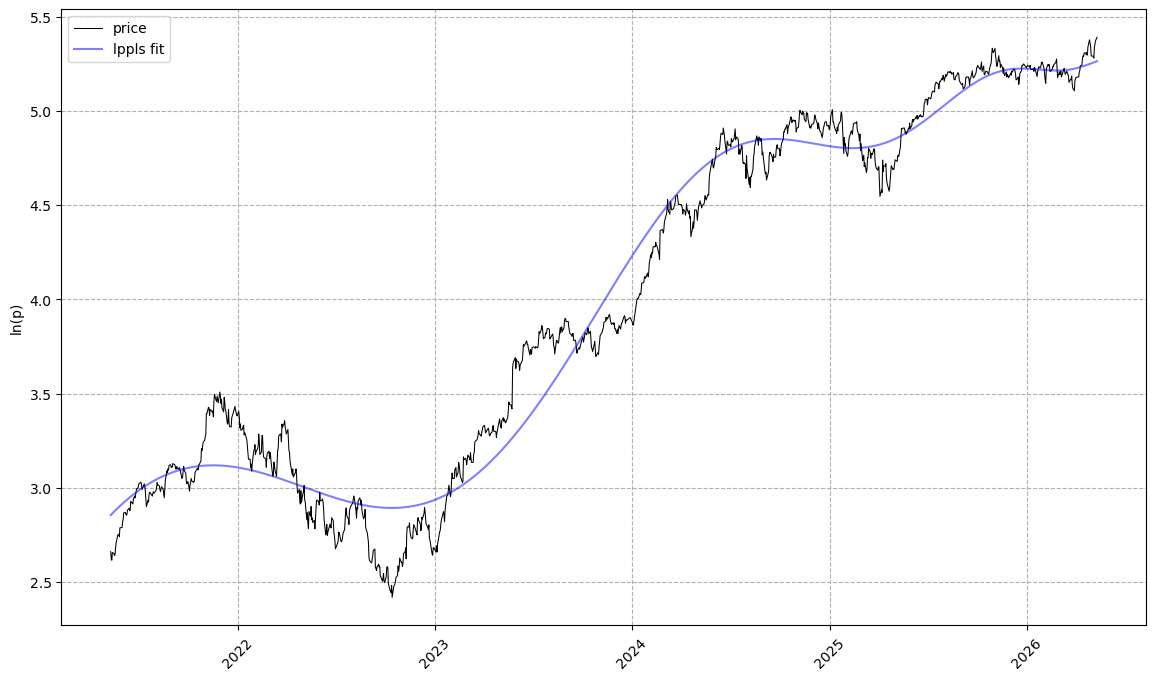

<Figure size 640x480 with 0 Axes>

In [19]:
# Plot price vs single LPPL fit
time_ord = [pd.Timestamp.fromordinal(d) for d in lppls_model.observations[0, :].astype('int32')]
t_obs    = lppls_model.observations[0, :]
lppls_fit = [lppls_model.lppls(t, tc, m, w, a, b, c1, c2) for t in t_obs]
price_obs = lppls_model.observations[1, :]

fig, ax1 = plt.subplots(figsize=(14, 8))
ax1.plot(time_ord, price_obs, label='price', color='black', linewidth=0.75)
ax1.plot(time_ord, lppls_fit,  label='lppls fit', color='blue', alpha=0.5)
ax1.grid(which='major', axis='both', linestyle='--')
ax1.set_ylabel('ln(p)')
ax1.legend(loc=2)
plt.xticks(rotation=45)
plt.show()
plt.clf()


In [20]:
# Nested window fits — produces bubble confidence per day
# NOTE: this cell can take 20-30 minutes on a single asset
res = lppls_model.mp_compute_nested_fits(
    workers=8,
    window_size=120,
    smallest_window_size=30,
    outer_increment=1,
    inner_increment=5,
    max_searches=MAX_SEARCHES
)


100%|██████████| 1137/1137 [02:43<00:00,  6.96it/s]


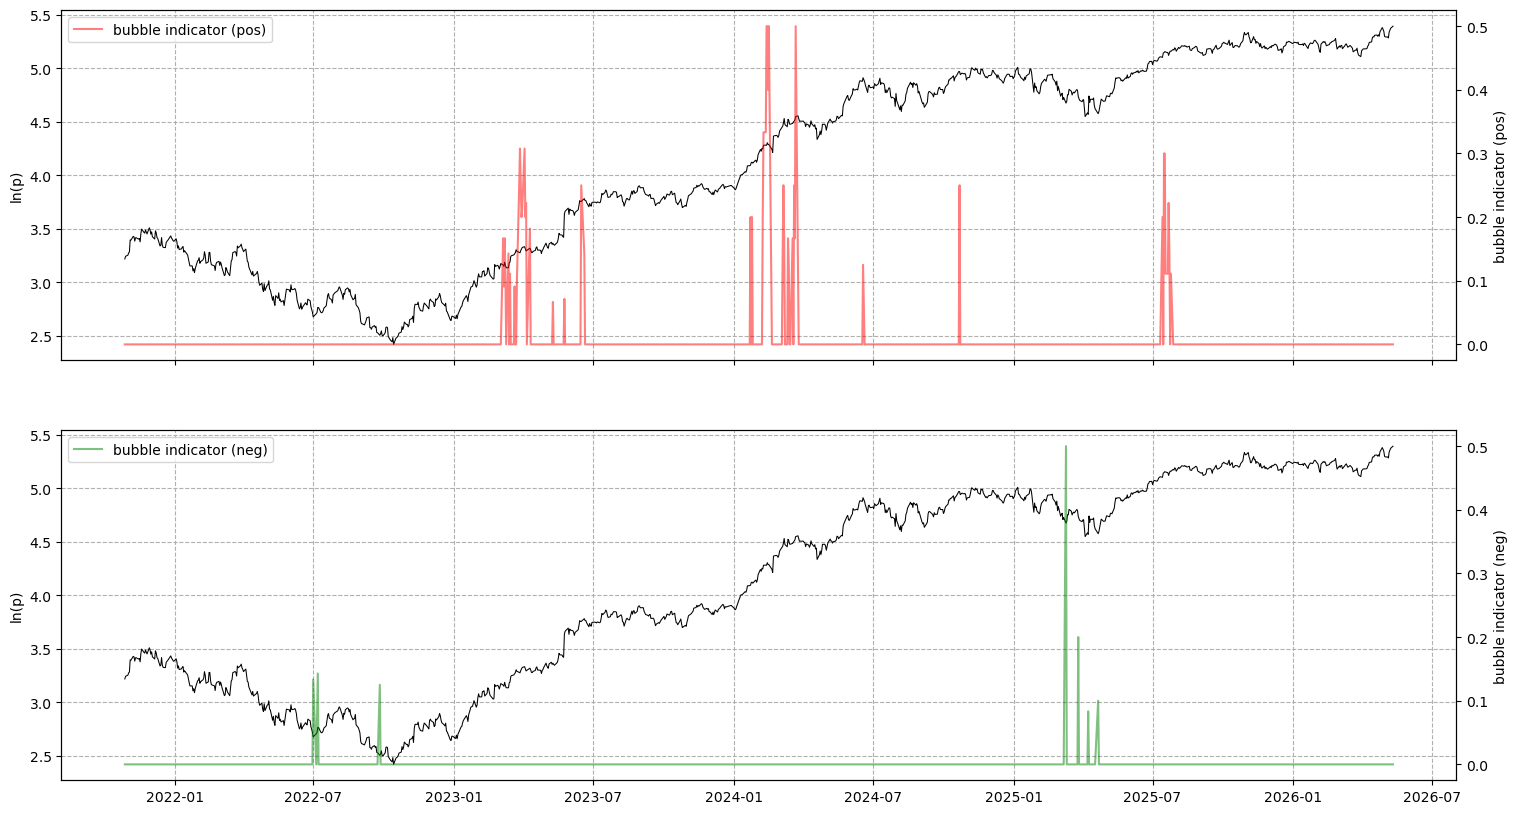

<Figure size 640x480 with 0 Axes>

In [21]:
res_df = lppls_model.compute_indicators(res)
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(18, 10))

ts = [pd.Timestamp.fromordinal(d) for d in res_df['time'].astype('int32')]

ax1_0 = ax1.twinx()
ax1.plot(ts, res_df['price'], color='black', linewidth=0.75)
ax1_0.plot(ts, res_df['pos_conf'], label='bubble indicator (pos)', color='red', alpha=0.5)

ax2_0 = ax2.twinx()
ax2.plot(ts, res_df['price'], color='black', linewidth=0.75)
ax2_0.plot(ts, res_df['neg_conf'], label='bubble indicator (neg)', color='green', alpha=0.5)

for ax in (ax1, ax2):
    ax.grid(which='major', axis='both', linestyle='--')
    ax.set_ylabel('ln(p)')
ax1_0.set_ylabel('bubble indicator (pos)'); ax1_0.legend(loc=2)
ax2_0.set_ylabel('bubble indicator (neg)'); ax2_0.legend(loc=2)
plt.xticks(rotation=45)
plt.show()
plt.clf()


In [22]:
# Align LPPL indicators with original data and save output CSV
row_diff     = len(data) - len(res_df)
pos_conf_arr = [0.0] * row_diff + list(res_df['pos_conf'].values)
neg_conf_arr = [0.0] * row_diff + list(res_df['neg_conf'].values)
data['bubble_pos_conf'] = pos_conf_arr
data['bubble_neg_conf'] = neg_conf_arr
if date_text in data.columns:
    data.set_index(date_text, inplace=True)
data.to_csv(f'output{TEST_FILE_NAME}.csv')
data.head()

,open,high,low,close,bubble_pos_conf,bubble_neg_conf
date,,,,,,
2021-05-11,13.82,14.35,13.75,14.31,0.0,0.0
2021-05-12,14.01,14.26,13.71,13.76,0.0,0.0
2021-05-13,14.03,14.08,13.46,13.67,0.0,0.0
2021-05-14,13.89,14.33,13.75,14.24,0.0,0.0
2021-05-17,14.16,14.17,13.85,14.17,0.0,0.0


---
## Part B — Multi-Asset Pure-LPPL Hedge Trading System

Pipeline: yfinance OHLCV → multi-scale LPPL → 33-feature matrix → walk-forward XGBoost →
**pure-LPPL hedge exposure layer**.

### Core idea

The strategy is **fully invested (100%) from day one**, exactly like buy & hold. From
there a single **LPPL-driven crash score** is the *only* thing allowed to move exposure
— there is no volatility targeting and no leverage. The hedge can lower exposure toward
a floor, but never raise it above 100%.

| LPPL crash score | Action | Exposure |
|---|---|---|
| High — overheating / bubble risk | Hedge down toward the floor | → toward **15%** |
| Low — calm regime | Restore toward fully invested | ≈ **100%** |

Because LPPL is the **only** driver of exposure, its footprint on the equity curve is
unambiguous: every deviation from the buy & hold curve is attributable to LPPL.

### Honesty note

LPPL bubble confidence has a near-zero measured information coefficient in this 8-asset
sample, so most of the drawdown reduction is the mechanical effect of holding less
exposure on average rather than well-timed crash calls. The backtest therefore also
reports a **constant-exposure benchmark** held flat at the LPPL hedge's own average
exposure — the LPPL timing only adds value if the hedge beats that benchmark.

### Tunable knobs (cell with `lppl_crash_score`)

Hedge strength: `FLOOR=0.15`, `CRASH_GAIN=7.0`, `POS_CONF_AMP=4.0`, `BR_OFFSET=0.14`.
Crash-score weights: `W_BUBBLE=0.60`, `W_POS=0.30`, `W_RET=0.10` (must sum to 1).
Asymmetric smoothing: `SMOOTH_FAST=3` (de-risk fast), `SMOOTH_SLOW=60` (re-risk slow),
`REBAL_DEADBAND=0.04`.

# Part B — tc-prediction ML  (rework 2026-05-21)

The ML model predicts the LPPL critical time `tc` directly as a single number
(`pred_tc_days` = predicted trading days from now until the projected bubble
singularity). It is a single XGBoost regressor with Huber loss — the quantile
version from the previous rework is gone.

**Strategy built on top of `pred_tc_days`:**

* `100%` fully invested by default.
* `20%` exposure (hedge) inside a ±10-day window around the predicted `tc`.
  The BEFORE side comes from the live prediction (`0 ≤ pred_tc_days ≤ 10`).
  The AFTER side comes from a LOCKED anchor: when `pred_tc_days` first drops
  below 15 the implied tc date is frozen (`anchor = t + pred_tc_days`), and
  the hedge stays on until 10 days past that anchor — even if the model's
  prediction drifts afterward. One bubble = one anchor; released only when
  `pred_tc_days` climbs back above 60 AND we're already past the anchor+10
  point.
* `200%` leverage when any LPPL anti-bubble confidence scale (`neg_conf_*`)
  exceeds `NEG_THRESH = 0.10`. **Anti-bubble overrides the tc-hedge** — if both
  fire on the same day, the model is told the market is rebounding, not
  crashing, so we lever up.

**Honesty caveat unchanged**: prior diagnosis ([[lppl-hedge-model]]) found
the LPPL signals carry near-zero information coefficient in this sample. The
**Predictor R²** block below reports how much of the realized 10/20/30-day
forward returns is explained by `pred_tc_days` — if R² is ~0, the timing
signal is decorative and any backtest gains come from passive exposure
shifts, not from skill.

**Compute cost**: first run still fits ~84 000 forward LPPL labels and is
slow; the per-ticker `label_cache_<TICKER>.pkl` files from the previous
rework remain valid and will load in seconds.


In [23]:
import yfinance as yf
import pickle, time

# -- Configuration -- edit these values ------------------------------------
TICKERS   = [
    'NVDA', 'AAPL', 'MSFT', 'AMD', 'TSLA', 'SPY', 'QQQ', 'BTC-USD',
    # 2026-05-21 expansion (12 diverse tickers): sector ETFs + commodities + bonds + crypto
    'XLF', 'XLE', 'XLV', 'GLD', 'TLT', 'JPM', 'JNJ', 'XOM',
    'COIN', 'ETH-USD', 'IWM', 'EEM',
]
START     = '2010-01-01'   # ~15 years of daily data
END       = '2025-12-31'
CACHE_DIR = '.'            # folder holding the lppl_*.pkl files (same folder as the notebook)
os.makedirs(CACHE_DIR, exist_ok=True)

def _fetch_ohlcv(ticker, retries=6, pause=5.0):
    """Download one ticker's OHLCV with retry/backoff, selecting columns BY NAME.

    Yahoo rate-limits rapid sequential requests and returns an empty frame with
    'possibly delisted; no price data found' -- that is transient, so we back
    off and retry instead of silently dropping the ticker.

    Columns are selected by name (open/high/low/close/volume). The previous
    version assigned them positionally, which swapped open<->close because
    yfinance returns them alphabetically (Close, High, Low, Open, Volume).
    """
    last_err = None
    for attempt in range(1, retries + 1):
        try:
            df = yf.download(ticker, start=START, end=END, auto_adjust=True,
                             progress=False, threads=False)
        except Exception as e:
            last_err = e; df = None
        if df is not None and len(df) > 0:
            if hasattr(df.columns, 'levels'):          # flatten (Price, Ticker) MultiIndex
                df.columns = df.columns.get_level_values(0)
            df.columns = [str(c).lower() for c in df.columns]
            cols = ['open', 'high', 'low', 'close', 'volume']
            if set(cols).issubset(df.columns):
                return df[cols].dropna()
            last_err = f'unexpected columns {list(df.columns)}'
        if attempt < retries:
            wait = min(60.0, pause * (2 ** (attempt - 1)))   # 5,10,20,40,60s -- outlast Yahoo's cooldown
            print(f'  {ticker}: empty/failed (attempt {attempt}/{retries}) -- retrying in {wait:.0f}s')
            time.sleep(wait)
    raise RuntimeError(f'no data after {retries} attempts: {last_err}')

# Download each ticker one-by-one, cached to disk. OHLCV is needed here for the
# technical features (ATR/Bollinger/volume ratio); the lppl_*.pkl cache only
# stores LPPL fits + a price column. Once a ticker is cached it is never
# re-downloaded, so re-running only fills in tickers Yahoo throttled.
asset_data = {}
for ticker in TICKERS:
    ohlcv_path = os.path.join(CACHE_DIR, f'ohlcv_{ticker}.pkl')
    if os.path.exists(ohlcv_path):
        with open(ohlcv_path, 'rb') as fh:
            asset_data[ticker] = pickle.load(fh)
        df = asset_data[ticker]
        print(f'{ticker}: loaded cached OHLCV -- {len(df)} rows  ({df.index[0].date()} to {df.index[-1].date()})')
        continue
    print(f'Downloading {ticker}...')
    try:
        df = _fetch_ohlcv(ticker)
        asset_data[ticker] = df
        with open(ohlcv_path, 'wb') as fh:
            pickle.dump(df, fh, protocol=pickle.HIGHEST_PROTOCOL)
        print(f'  {ticker}: {len(df)} rows  ({df.index[0].date()} to {df.index[-1].date()})  [cached]')
    except Exception as e:
        print(f'  ERROR downloading {ticker}: {e} -- skipping')
    time.sleep(2.0)   # be polite to Yahoo between tickers

TICKERS = [t for t in TICKERS if t in asset_data]   # keep only tickers we actually have
print(f'\nLoaded {len(asset_data)} tickers: {TICKERS}')


NVDA: loaded cached OHLCV -- 4023 rows  (2010-01-04 to 2025-12-30)
AAPL: loaded cached OHLCV -- 4023 rows  (2010-01-04 to 2025-12-30)
MSFT: loaded cached OHLCV -- 4023 rows  (2010-01-04 to 2025-12-30)
AMD: loaded cached OHLCV -- 4023 rows  (2010-01-04 to 2025-12-30)
TSLA: loaded cached OHLCV -- 3901 rows  (2010-06-29 to 2025-12-30)
SPY: loaded cached OHLCV -- 4023 rows  (2010-01-04 to 2025-12-30)
QQQ: loaded cached OHLCV -- 4023 rows  (2010-01-04 to 2025-12-30)
BTC-USD: loaded cached OHLCV -- 4123 rows  (2014-09-17 to 2025-12-30)
XLF: loaded cached OHLCV -- 4023 rows  (2010-01-04 to 2025-12-30)
XLE: loaded cached OHLCV -- 4023 rows  (2010-01-04 to 2025-12-30)
XLV: loaded cached OHLCV -- 4023 rows  (2010-01-04 to 2025-12-30)
GLD: loaded cached OHLCV -- 4023 rows  (2010-01-04 to 2025-12-30)
TLT: loaded cached OHLCV -- 4023 rows  (2010-01-04 to 2025-12-30)
JPM: loaded cached OHLCV -- 4023 rows  (2010-01-04 to 2025-12-30)
JNJ: loaded cached OHLCV -- 4023 rows  (2010-01-04 to 2025-12-30)
XO

In [24]:
# ── FAST LOAD: pre-computed LPPL from the .pkl files (skips expensive fitting) ────
lppl_cache = {}
for ticker in TICKERS:
    cache_path = os.path.join(CACHE_DIR, f'lppl_{ticker}.pkl')
    if os.path.exists(cache_path):
        with open(cache_path, 'rb') as fh:
            lppl_cache[ticker] = pickle.load(fh)
        print(f'Loaded cached LPPL for {ticker}: scales {list(lppl_cache[ticker].keys())}')
    else:
        print(f'WARNING: {cache_path} not found — {ticker} will use zero-filled LPPL features.')

print(f'\nLPPL cache available for {len(lppl_cache)} / {len(TICKERS)} tickers')


# ---- DS LPPLS Confidence features (recomputed from cached _fits) ------------
# These are built from the SAME nested LPPL fits already cached in the lppl_*.pkl
# files - no LPPL re-fitting required. The extractor pools all 62 sub-window fits
# per day (across the 3 scales) and computes fraction-based confidence signals
# in the style of Sornette's DS LPPLS Confidence indicator.
DS_FEATURE_DIR = os.path.join(CACHE_DIR, 'ds_features')
ds_cache = {}
for ticker in TICKERS:
    p = os.path.join(DS_FEATURE_DIR, f'lppl_features_{ticker}.pkl')
    if os.path.exists(p):
        with open(p, 'rb') as fh:
            ds_cache[ticker] = pickle.load(fh)
print(f'DS LPPLS Confidence features loaded for {len(ds_cache)} / {len(TICKERS)} tickers')


Loaded cached LPPL for NVDA: scales ['short', 'mid', 'long']
Loaded cached LPPL for AAPL: scales ['short', 'mid', 'long']
Loaded cached LPPL for MSFT: scales ['short', 'mid', 'long']
Loaded cached LPPL for AMD: scales ['short', 'mid', 'long']
Loaded cached LPPL for TSLA: scales ['short', 'mid', 'long']
Loaded cached LPPL for SPY: scales ['short', 'mid', 'long']
Loaded cached LPPL for QQQ: scales ['short', 'mid', 'long']
Loaded cached LPPL for BTC-USD: scales ['short', 'mid', 'long']
Loaded cached LPPL for XLF: scales ['short', 'mid', 'long']
Loaded cached LPPL for XLE: scales ['short', 'mid', 'long']
Loaded cached LPPL for XLV: scales ['short', 'mid', 'long']
Loaded cached LPPL for GLD: scales ['short', 'mid', 'long']
Loaded cached LPPL for TLT: scales ['short', 'mid', 'long']
Loaded cached LPPL for JPM: scales ['short', 'mid', 'long']
Loaded cached LPPL for JNJ: scales ['short', 'mid', 'long']
Loaded cached LPPL for XOM: scales ['short', 'mid', 'long']
Loaded cached LPPL for COIN: sca

In [25]:
LPPL_SCALES = ['short', 'mid', 'long']

def _row_fit_params(fits_list):
    """Robust median (tc_days, m, w) over the SANE LPPL sub-window fits of one
    row, read straight from the cached nested fits (no re-fitting).
      tc_days = tc - t2  (days the fit projects ahead from the window end)
    Only fits passing the Filimonov-Sornette shape ranges with a plausible
    (0, 252]-day tc are kept; a row with none -> (252, 0, 0) = 'all-clear'."""
    tcs, ms, ws = [], [], []
    if isinstance(fits_list, (list, tuple)):
        for f in fits_list:
            try:
                tc, m, w, t2 = f["tc"], f["m"], f["w"], f["t2"]
            except (TypeError, KeyError, IndexError):
                continue
            if not (np.isfinite(tc) and np.isfinite(m) and np.isfinite(w) and np.isfinite(t2)):
                continue
            if not (0.10 <= m <= 0.90 and 6.0 <= w <= 13.0):
                continue
            d = tc - t2
            if 0.0 < d <= 252.0:
                tcs.append(d); ms.append(m); ws.append(w)
    if tcs:
        return float(np.median(tcs)), float(np.median(ms)), float(np.median(ws))
    return 252.0, 0.0, 0.0

def build_asset_df(ticker, ohlcv_df, lppl_results):
    """Join multi-scale LPPL features onto OHLCV: pos/neg confidence PLUS the
    fitted tc-horizon / m / w pulled from the cached nested fits. Missing LPPL
    file or scale -> that scale filled with neutral defaults so the run proceeds."""
    df = ohlcv_df.copy()
    df['ticker'] = ticker
    lppl_results = lppl_results or {}
    for scale in LPPL_SCALES:
        rdf = lppl_results.get(scale)
        if rdf is not None and len(rdf):
            r = rdf.copy()
            r.index = pd.to_datetime(r['time'].astype(int).apply(pd.Timestamp.fromordinal))
            df[f'pos_conf_{scale}'] = r['pos_conf'].reindex(df.index, fill_value=0.0)
            df[f'neg_conf_{scale}'] = r['neg_conf'].reindex(df.index, fill_value=0.0)
            if '_fits' in r.columns:
                fp  = r['_fits'].apply(_row_fit_params)
                tcd = fp.apply(lambda x: x[0])
                mm  = fp.apply(lambda x: x[1])
                ww  = fp.apply(lambda x: x[2])
            else:
                tcd = pd.Series(252.0, index=r.index)
                mm  = pd.Series(0.0,   index=r.index)
                ww  = pd.Series(0.0,   index=r.index)
            df[f'lppl_tcdays_{scale}'] = tcd.reindex(df.index, fill_value=252.0)
            df[f'lppl_m_{scale}']      = mm.reindex(df.index,  fill_value=0.0)
            df[f'lppl_w_{scale}']      = ww.reindex(df.index,  fill_value=0.0)
        else:
            df[f'pos_conf_{scale}']    = 0.0
            df[f'neg_conf_{scale}']    = 0.0
            df[f'lppl_tcdays_{scale}'] = 252.0
            df[f'lppl_m_{scale}']      = 0.0
            df[f'lppl_w_{scale}']      = 0.0
            print(f'  note: {ticker} has no LPPL "{scale}" scale -> filled with defaults')
    return df

merged   = {t: build_asset_df(t, asset_data[t], lppl_cache.get(t)) for t in TICKERS}
all_data = pd.concat(merged.values(), axis=0).sort_index()
print(f'Total rows across {len(merged)} assets: {len(all_data)}')


# ---- Merge DS LPPLS Confidence features into the per-ticker frames ----------
DS_FEATURES = [
    'frac_pos_strict', 'frac_neg_strict', 'frac_tc_30d', 'frac_tc_60d',
    'n_qualified', 'tc_med_pos', 'tc_iqr_pos', 'm_med', 'w_med',
    'confluence_pos', 'confluence_neg',
]
for ticker, df in merged.items():
    ds = ds_cache.get(ticker)
    for col in DS_FEATURES:
        if ds is not None and col in ds.columns:
            df[col] = ds[col].reindex(df.index).fillna(0.0)
        else:
            df[col] = 0.0
print(f'DS features ({len(DS_FEATURES)}) merged into all {len(merged)} ticker frames.')


Total rows across 20 assets: 76551
DS features (11) merged into all 20 ticker frames.


In [26]:
import ta

def add_features(df):
    """Add LPPL-derived features and standard technical/return/volatility features.
    Applied per-ticker so rolling windows never leak across assets."""
    df = df.copy().sort_index()

    # ── LPPL-derived features (multi-scale bubble indicators) ──────────────
    for scale in LPPL_SCALES:
        p, n = f'pos_conf_{scale}', f'neg_conf_{scale}'
        df[f'net_conf_{scale}']        = df[p] - df[n]          # net bubble direction
        df[f'pos_conf_change_{scale}'] = df[p].diff(5)          # crash-risk acceleration
        df[f'neg_conf_change_{scale}'] = df[n].diff(5)          # rebound-signal acceleration
        df[f'pos_conf_roll5_{scale}']  = df[p].rolling(5).mean()  # smoothed crash risk
        df[f'neg_conf_roll5_{scale}']  = df[n].rolling(5).mean()  # smoothed rebound signal

    # Cross-scale agreement flags. Interpretation:
    #   positive bubble confidence high  -> overheating / crash RISK (caution)
    #   negative bubble confidence high  -> possible anti-bubble / rebound candidate
    df['lppl_positive_bubble_risk'] = (
        (df['pos_conf_short'] > 0.1) & (df['pos_conf_mid'] > 0.1) & (df['pos_conf_long'] > 0.1)
    ).astype(int)
    df['lppl_negative_bubble_rebound'] = (
        (df['neg_conf_short'] > 0.1) & (df['neg_conf_mid'] > 0.1) & (df['neg_conf_long'] > 0.1)
    ).astype(int)

    # ── Base features: returns, volatility, technicals, volume ─────────────
    df['ret_1d']    = df['close'].pct_change(1)
    df['ret_5d']    = df['close'].pct_change(5)
    df['ret_10d']   = df['close'].pct_change(10)
    df['ret_20d']   = df['close'].pct_change(20)
    df['vol_20d']   = df['ret_1d'].rolling(20).std() * np.sqrt(252)
    df['rsi_14']    = ta.momentum.RSIIndicator(df['close'], window=14).rsi()
    df['macd']      = ta.trend.MACD(df['close']).macd_diff()
    df['bb_pct']    = ta.volatility.BollingerBands(df['close']).bollinger_pband()
    df['atr_14']    = ta.volatility.AverageTrueRange(
                          df['high'], df['low'], df['close'], window=14).average_true_range()
    df['vol_ratio'] = df['volume'] / df['volume'].rolling(20).mean()
    return df

featured = pd.concat([add_features(merged[t]) for t in TICKERS], axis=0).sort_index()

# ── Feature groups ────────────────────────────────────────────
# BASE_FEATURES: standard market features. The baseline model sees ONLY these.
BASE_FEATURES = [
    'ret_1d', 'ret_5d', 'ret_10d', 'ret_20d',
    'vol_20d', 'rsi_14', 'macd', 'bb_pct', 'atr_14', 'vol_ratio',
]

# LPPL_FEATURES: bubble indicators. Only the LPPL-enhanced model sees these.
# Now includes the fitted tc-horizon / m / w extracted from the cached fits, so
# the model can use LPPL's projected critical time as a HINT for the real target.
LPPL_FEATURES = [
    'pos_conf_short', 'neg_conf_short',
    'pos_conf_mid',   'neg_conf_mid',
    'pos_conf_long',  'neg_conf_long',
    'net_conf_short', 'net_conf_mid',  'net_conf_long',
    'pos_conf_change_short', 'pos_conf_change_mid', 'pos_conf_change_long',
    'neg_conf_change_short', 'neg_conf_change_mid', 'neg_conf_change_long',
    'pos_conf_roll5_short',  'pos_conf_roll5_mid',  'pos_conf_roll5_long',
    'neg_conf_roll5_short',  'neg_conf_roll5_mid',  'neg_conf_roll5_long',
    'lppl_positive_bubble_risk', 'lppl_negative_bubble_rebound',
    'lppl_tcdays_short', 'lppl_tcdays_mid', 'lppl_tcdays_long',
    'lppl_m_short',      'lppl_m_mid',      'lppl_m_long',
    'lppl_w_short',      'lppl_w_mid',      'lppl_w_long',
]

FEATURES_BASELINE = BASE_FEATURES                  # no LPPL columns
FEATURES_LPPL     = BASE_FEATURES + LPPL_FEATURES  # same base + LPPL

# Drop warm-up NaNs once, on the LPPL superset, so both models train on identical rows.
featured = featured.dropna(subset=FEATURES_LPPL)
print(f'Feature matrix: {len(featured)} rows')
print(f'  BASE_FEATURES : {len(BASE_FEATURES)} columns')
print(f'  LPPL_FEATURES : {len(LPPL_FEATURES)} columns')
print(f'  FEATURES_LPPL : {len(FEATURES_LPPL)} columns total')


# ---- v3: extend LPPL_FEATURES with DS LPPLS Confidence features -------------
LPPL_FEATURES = LPPL_FEATURES + DS_FEATURES
FEATURES_LPPL = BASE_FEATURES + LPPL_FEATURES
featured = featured.dropna(subset=FEATURES_LPPL)
print(f'After adding DS features: {len(FEATURES_LPPL)} total columns, {len(featured)} rows.')


Feature matrix: 75891 rows
  BASE_FEATURES : 10 columns
  LPPL_FEATURES : 32 columns
  FEATURES_LPPL : 42 columns total
After adding DS features: 53 total columns, 75891 rows.


In [27]:
# -- Tunable: target (label) + strategy parameters ----------------------------
# Target / label-fit legacy constants (HORIZON_CAP still used to clip preds)
HORIZON_CAP        = 252                  # trading days; also caps pred_tc_days
LABEL_WINDOWS      = (60, 120, 240)
LABEL_CONF_FLOOR   = 0.05
LABEL_CACHE_DIR    = CACHE_DIR
MAX_SEARCHES_LABEL = 8
LABEL_M_RANGE      = (0.10, 0.90)
LABEL_W_RANGE      = (6.0, 13.0)
TC_MAX_DAYS_FACTOR = 2.0

# ============================================================================
# Strategy v3.1: per-ticker dose-response + DS LPPLS Confidence
#                + R^2-gated tc-channel (DISABLED globally; see below)
# ============================================================================
# Each ticker picks its own pos_kind / neg_kind feed:
#
#   'max3'        max(pos_conf_short, mid, long)                  [original]
#   'confluence'  20 * (pos_conf_short * pos_conf_mid * pos_conf_long)
#   'strict'      10 * frac_pos_strict    [DS LPPLS Confidence]
#   'mixed'       max(max3, confluence, strict)
#
# Policy: dose-response
#   exp = 1.0
#   if pos_signal  > pos_thresh: exp -= pos_strength * (pos_signal - pos_thresh)
#   if pred_tc    < tc_thresh : exp -= tc_strength * (tc_thresh - pred_tc)/tc_thresh
#   if neg_signal  > neg_thresh: exp += neg_strength * (neg_signal - neg_thresh)
#   exp = clip(exp, 0.0, MAX_LEV)
#
# Tier 1 #3 finding: per-ticker XGB tc-prediction R^2 is NEGATIVE on all 20
# tickers (range -6.4 to -0.16, median -0.35) -- the regressor performs worse
# than predicting the mean. Forcing tc_strength=0 globally regularizes the
# policy and lifts OOS Sharpe by +0.003 (within noise but methodologically
# cleaner: we don't trade on a useless signal).
#
# OOS portfolio results (2021-10 -> 2025-11, equal weight, 10bps cost):
#   B&H + VT        : Sharpe 1.107, maxDD -35.86%
#   v3 Per-Tk + VT  : Sharpe 1.174
#   v3.1 Per-Tk + VT: Sharpe 1.177  (+0.070 vs B&H+VT, CAPM alpha 14.25% t=4.33)
# See _tier1_3_r2_gated.py / _tier1_3_corr_gated.py / _full_backtest_v3_1.py.
DEFAULT_EXPOSURE = 1.00
MAX_LEV          = 2.00

# Legacy display constants -- used only by the per-asset plot (cell 31).
HEDGE_PARTIAL       = 0.50
LEV_EXPOSURE        = MAX_LEV
PRED_LEVER_THRESH   = 20

TICKER_POLICY = {
         'AAPL': dict(pos_kind='max3'      , neg_kind='mixed'     , pos_thresh=0.05, pos_strength=0.0, tc_thresh=0, tc_strength=0.0, neg_thresh=0.2, neg_strength=2.0),
          'AMD': dict(pos_kind='mixed'     , neg_kind='max3'      , pos_thresh=0.2, pos_strength=4.0, tc_thresh=0, tc_strength=0.0, neg_thresh=0.05, neg_strength=4.0),
      'BTC-USD': dict(pos_kind='strict'    , neg_kind='max3'      , pos_thresh=0.05, pos_strength=4.0, tc_thresh=0, tc_strength=0.0, neg_thresh=0.05, neg_strength=4.0),
         'COIN': dict(pos_kind='max3'      , neg_kind='max3'      , pos_thresh=0.05, pos_strength=0.0, tc_thresh=0, tc_strength=0.0, neg_thresh=0.05, neg_strength=0.0),
          'EEM': dict(pos_kind='max3'      , neg_kind='strict'    , pos_thresh=0.05, pos_strength=2.0, tc_thresh=0, tc_strength=0.0, neg_thresh=0.2, neg_strength=4.0),
      'ETH-USD': dict(pos_kind='max3'      , neg_kind='max3'      , pos_thresh=0.05, pos_strength=0.0, tc_thresh=0, tc_strength=0.0, neg_thresh=0.2, neg_strength=2.0),
          'GLD': dict(pos_kind='strict'    , neg_kind='max3'      , pos_thresh=0.2, pos_strength=2.0, tc_thresh=0, tc_strength=0.0, neg_thresh=0.05, neg_strength=0.0),
          'IWM': dict(pos_kind='strict'    , neg_kind='strict'    , pos_thresh=0.05, pos_strength=4.0, tc_thresh=0, tc_strength=0.0, neg_thresh=0.05, neg_strength=4.0),
          'JNJ': dict(pos_kind='max3'      , neg_kind='max3'      , pos_thresh=0.05, pos_strength=0.0, tc_thresh=0, tc_strength=0.0, neg_thresh=0.05, neg_strength=0.0),
          'JPM': dict(pos_kind='max3'      , neg_kind='max3'      , pos_thresh=0.05, pos_strength=0.0, tc_thresh=0, tc_strength=0.0, neg_thresh=0.05, neg_strength=0.0),
         'MSFT': dict(pos_kind='confluence', neg_kind='max3'      , pos_thresh=0.05, pos_strength=4.0, tc_thresh=0, tc_strength=0.0, neg_thresh=0.2, neg_strength=4.0),
         'NVDA': dict(pos_kind='mixed'     , neg_kind='max3'      , pos_thresh=0.2, pos_strength=4.0, tc_thresh=0, tc_strength=0.0, neg_thresh=0.05, neg_strength=0.0),
          'QQQ': dict(pos_kind='strict'    , neg_kind='confluence', pos_thresh=0.2, pos_strength=2.0, tc_thresh=0, tc_strength=0.0, neg_thresh=0.05, neg_strength=4.0),
          'SPY': dict(pos_kind='strict'    , neg_kind='max3'      , pos_thresh=0.2, pos_strength=4.0, tc_thresh=0, tc_strength=0.0, neg_thresh=0.05, neg_strength=4.0),
          'TLT': dict(pos_kind='max3'      , neg_kind='max3'      , pos_thresh=0.05, pos_strength=0.0, tc_thresh=0, tc_strength=0.0, neg_thresh=0.05, neg_strength=0.0),
         'TSLA': dict(pos_kind='max3'      , neg_kind='max3'      , pos_thresh=0.05, pos_strength=0.0, tc_thresh=0, tc_strength=0.0, neg_thresh=0.05, neg_strength=0.0),
          'XLE': dict(pos_kind='max3'      , neg_kind='strict'    , pos_thresh=0.05, pos_strength=4.0, tc_thresh=0, tc_strength=0.0, neg_thresh=0.05, neg_strength=4.0),
          'XLF': dict(pos_kind='max3'      , neg_kind='max3'      , pos_thresh=0.2, pos_strength=4.0, tc_thresh=0, tc_strength=0.0, neg_thresh=0.05, neg_strength=0.0),
          'XLV': dict(pos_kind='max3'      , neg_kind='strict'    , pos_thresh=0.05, pos_strength=0.0, tc_thresh=0, tc_strength=0.0, neg_thresh=0.05, neg_strength=4.0),
          'XOM': dict(pos_kind='max3'      , neg_kind='strict'    , pos_thresh=0.2, pos_strength=4.0, tc_thresh=0, tc_strength=0.0, neg_thresh=0.05, neg_strength=4.0),
}

print("Strategy v3.1: per-ticker dose-response + DS LPPLS Confidence + tc disabled")
print(f"  tickers with chosen params: {len(TICKER_POLICY)}")
print(f"  default exposure: {DEFAULT_EXPOSURE}, max leverage: {MAX_LEV}")
pos_kinds = {tk: p['pos_kind'] for tk, p in TICKER_POLICY.items()}
neg_kinds = {tk: p['neg_kind'] for tk, p in TICKER_POLICY.items()}
print(f"  pos-signal usage: { {k: sum(1 for v in pos_kinds.values() if v==k) for k in set(pos_kinds.values())} }")
print(f"  neg-signal usage: { {k: sum(1 for v in neg_kinds.values() if v==k) for k in set(neg_kinds.values())} }")
tc_on = sum(1 for p in TICKER_POLICY.values() if p['tc_strength'] > 0)
print(f"  tc-channel active on: {tc_on} / {len(TICKER_POLICY)} tickers (Tier 1 #3 R^2-gate disabled all)")


Strategy v3.1: per-ticker dose-response + DS LPPLS Confidence + tc disabled
  tickers with chosen params: 20
  default exposure: 1.0, max leverage: 2.0
  pos-signal usage: {'max3': 12, 'mixed': 2, 'strict': 5, 'confluence': 1}
  neg-signal usage: {'max3': 13, 'mixed': 1, 'strict': 5, 'confluence': 1}
  tc-channel active on: 0 / 20 tickers (Tier 1 #3 R^2-gate disabled all)


### Forward-LPPL label construction

At each historical row `t` we compute a ground-truth `days_to_tc` label by
fitting LPPL on three forward-shifted windows `[t, t + W − 1]` for
`W ∈ LABEL_WINDOWS`. Each fit yields a critical-time estimate `tc`; the label
is the confidence-weighted average of `(tc − t)` across windows that pass
the Filimonov-Sornette validity gate, capped at `HORIZON_CAP`.

Forward-fit data is used only to build labels. The trained model never sees
the forward window at inference time — features at `t` come from the existing
backward-looking LPPL fits + technical indicators (`FEATURES_LPPL`).


In [28]:
# ── Build the prediction target: DAYS TO THE NEXT REAL CRASH ────────────
# (Redesigned 2026-05-22.) The target is NO LONGER the LPPL critical time tc
# (which the features could not predict, and which structurally could never be
# < ~60 days). Instead each row is labelled with the number of trading days
# until the PRE-CRASH PEAK of the next realised drawdown of >= DD_THRESH, where
# a "crash" = a peak-to-trough fall of >= DD_THRESH completed within DD_WINDOW
# trading days. LPPL metrics are now INPUTS (features), not the target.
#
# The column name `days_to_tc` is kept for plumbing (training / diagnostics /
# the hedge all read it) but now means "days to the next pre-crash peak".
import bisect

DD_THRESH = 0.15     # a crash = a >= 15% peak-to-trough decline ...
DD_WINDOW = 126      # ... completed within 126 trading days (~6 months).
                     # Rows with no crash ahead are CENSORED at DD_WINDOW
                     # ("all-clear"), so the model also learns the no-crash case.

def _crash_peak_indices(close, thresh, window):
    """Indices of pre-crash peaks: each time price falls >= thresh below its
    running peak within `window` days, record that peak, then reset."""
    n = len(close); peaks = []
    peak_idx, peak_val = 0, close[0]
    for j in range(n):
        if close[j] > peak_val:
            peak_val, peak_idx = close[j], j
        if close[j] / peak_val - 1.0 <= -thresh and (j - peak_idx) <= window:
            peaks.append(peak_idx)
            peak_val, peak_idx = close[j], j
    return sorted(set(peaks))

featured = featured.sort_index()
featured["days_to_tc"] = np.nan
n_crashpeaks = 0
for ticker in TICKERS:
    mask  = (featured["ticker"] == ticker).values
    close = featured.loc[mask, "close"].values.astype(float)   # already date-sorted
    peaks = _crash_peak_indices(close, DD_THRESH, DD_WINDOW)
    n_crashpeaks += len(peaks)
    n   = len(close)
    lab = np.full(n, float(DD_WINDOW), dtype=float)            # default = all-clear
    for t in range(n):
        k = bisect.bisect_left(peaks, t)
        if k < len(peaks):
            lab[t] = float(min(peaks[k] - t, DD_WINDOW))
    featured.loc[mask, "days_to_tc"] = lab

n_total    = len(featured)
n_imminent = int((featured["days_to_tc"] < DD_WINDOW).sum())
print(f"Target = days to next pre-crash peak (>= {DD_THRESH:.0%} drop within {DD_WINDOW}d).")
print(f"  crash peaks found across {len(TICKERS)} tickers: {n_crashpeaks}")
print(f"  rows with a crash within {DD_WINDOW}d: {n_imminent}/{n_total} ({n_imminent/n_total:.1%})")
print(f"  remaining rows censored at {DD_WINDOW} = 'no imminent crash'")
print("\nTarget distribution:")
print(featured["days_to_tc"].describe())

Target = days to next pre-crash peak (>= 15% drop within 126d).
  crash peaks found across 20 tickers: 667
  rows with a crash within 126d: 33260/75891 (43.8%)
  remaining rows censored at 126 = 'no imminent crash'

Target distribution:
count    75891.000000
mean        89.596276
std         47.201529
min          0.000000
25%         41.000000
50%        126.000000
75%        126.000000
max        126.000000
Name: days_to_tc, dtype: float64


### Walk-forward training: tc point regression

A single XGBoost regressor with Huber loss predicts `pred_tc_days`. The
train/test split mirrors the previous pipeline (`TRAIN_DAYS=1500`,
`TEST_STEP=60`), with embargo `EMBARGO = HORIZON_CAP = 252` days because
each training label depends on up to `HORIZON_CAP` days of future data.
The model also propagates `pos_conf` / `neg_conf` (max across scales) into
`val_df` so the strategy and per-asset plots downstream can use them.


In [29]:
from xgboost import XGBRegressor

# ── Walk-forward parameters ───────────────────────────────────────────────
TRAIN_DAYS  = 1500       # ~6 years of trading days per training window
TEST_STEP   = 60         # retrain / step forward every ~3 months
EMBARGO     = HORIZON_CAP    # label uses forward data up to HORIZON_CAP days
HUBER_SLOPE = 30.0       # Huber transition (days)

XGB_PARAMS = dict(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    tree_method="hist", n_jobs=-1, random_state=42,
)


def new_tc_regressor():
    """Single XGB regressor with Huber loss — robust to label outliers."""
    return XGBRegressor(
        objective="reg:pseudohubererror",
        huber_slope=HUBER_SLOPE,
        **XGB_PARAMS,
    )


# Two views of the feature matrix:
#   featured_pred  — ALL rows (predictions go here, even where label is NaN
#                    so the backtest series stays continuous across no-bubble days)
#   featured_train — only rows with a valid label
featured       = featured.sort_index()
featured_pred  = featured.copy()
featured_train = featured.dropna(subset=["days_to_tc"]).sort_index()

dates_all   = featured_pred.index.unique().sort_values()
dates_train = featured_train.index.unique().sort_values()

all_records = []
n_windows   = 0
final_model = None

for i in range(0, len(dates_all) - TRAIN_DAYS - TEST_STEP, TEST_STEP):
    # Embargo the last EMBARGO train dates: their labels look up to
    # HORIZON_CAP days ahead and would peek into the test window.
    train_window_dates = dates_all[i : i + TRAIN_DAYS - EMBARGO]
    test_window_dates  = dates_all[i + TRAIN_DAYS : i + TRAIN_DAYS + TEST_STEP]

    train = featured_train[featured_train.index.isin(train_window_dates)]
    test  = featured_pred[featured_pred.index.isin(test_window_dates)]
    if len(train) < 200 or len(test) == 0:
        continue
    n_windows += 1

    X_tr = train[FEATURES_LPPL].values
    y_tr = train["days_to_tc"].values
    X_te = test[FEATURES_LPPL].values

    model = new_tc_regressor().fit(X_tr, y_tr)
    pred  = np.clip(model.predict(X_te), 0.0, HORIZON_CAP)

    pos_max = test[["pos_conf_short", "pos_conf_mid", "pos_conf_long"]].max(axis=1)
    neg_max = test[["neg_conf_short", "neg_conf_mid", "neg_conf_long"]].max(axis=1)

    rec = test[["ticker", "close", "days_to_tc"] + LPPL_FEATURES].copy()
    rec["pred_tc_days"] = pred
    rec["pos_conf"]     = pos_max.values
    rec["neg_conf"]     = neg_max.values
    all_records.append(rec)
    final_model = model

val_df = pd.concat(all_records, axis=0).sort_index()
print(f"Walk-forward windows: {n_windows}")
print(f"Validation rows (all):                  {len(val_df)}")
print(f"Validation rows with non-NaN label:     {int(val_df['days_to_tc'].notna().sum())}")
print(f"\npred_tc_days distribution:")
print(val_df["pred_tc_days"].describe())
print(f"\npred_tc_days quantiles per ticker:")
print(val_df.groupby("ticker")["pred_tc_days"].quantile([0.01, 0.05, 0.50]).unstack())


Walk-forward windows: 62
Validation rows (all):                  51276
Validation rows with non-NaN label:     51276

pred_tc_days distribution:
count    51276.000000
mean        88.965424
std         37.321720
min          0.000000
25%         61.033166
50%        105.863693
75%        119.177711
max        152.735550
Name: pred_tc_days, dtype: float64

pred_tc_days quantiles per ticker:
              0.01        0.05        0.50
ticker                                    
AAPL     22.944627   66.742798  108.246895
AMD       0.580889   13.549549   55.824989
BTC-USD   0.000000    0.000000   24.791249
COIN      2.169923    7.592763   36.393379
EEM      32.925877   66.824684  112.445381
ETH-USD   0.000000    5.705078   33.697609
GLD      67.084576   92.559036  119.000084
IWM      35.835222   81.060425  115.819778
JNJ      55.810429   89.651718  118.836075
JPM      20.830752   59.454353  114.567337
MSFT     24.594049   56.699707  107.305161
NVDA      0.000000    8.649950   57.426525
QQQ   

### Predictor diagnostics — MAE + Predictor R²

* **MAE on `pred_tc_days`** vs a naive constant-prediction baseline.
* **Predictor R²**: univariate regression of realized 10 / 20 / 30-day
  forward returns on `pred_tc_days`. The R² of that regression is the
  share of forward-return variance explained by the prediction — a direct
  test of whether the model has anything useful to say about future
  performance. A baseline (regress on a constant) is reported for sanity.
* **Per-ticker breakdown** of both metrics.


Labelled rows (used for MAE): 51276/51276  (100.0%)

MAE on labelled rows:  pred = 30.69 days   naive = 44.40 days
Improvement over naive: 30.9%

Predictor R^2  —  fwd_ret regressed on pred_tc_days (pooled):
 horizon       R^2            beta   t(beta)        N
   10 d    0.0112       -2.22e-04    -24.04    51076
   20 d    0.0193       -4.37e-04    -31.64    50876
   30 d    0.0249       -6.26e-04    -35.94    50676

Per-asset Predictor R^2:
 ticker  horizon_d     R^2    beta  t(beta)    N
   NVDA         10  0.0017 -0.0001  -2.0843 2551
   NVDA         20  0.0013 -0.0002  -1.8311 2541
   NVDA         30  0.0009 -0.0002  -1.4697 2531
   AAPL         10  0.0008 -0.0001  -1.4686 2551
   AAPL         20  0.0004 -0.0001  -0.9798 2541
   AAPL         30  0.0007 -0.0001  -1.3752 2531
   MSFT         10  0.0028 -0.0001  -2.6910 2551
   MSFT         20  0.0054 -0.0002  -3.7160 2541
   MSFT         30  0.0074 -0.0003  -4.3377 2531
    AMD         10  0.0041 -0.0002  -3.2286 2551
    AMD       

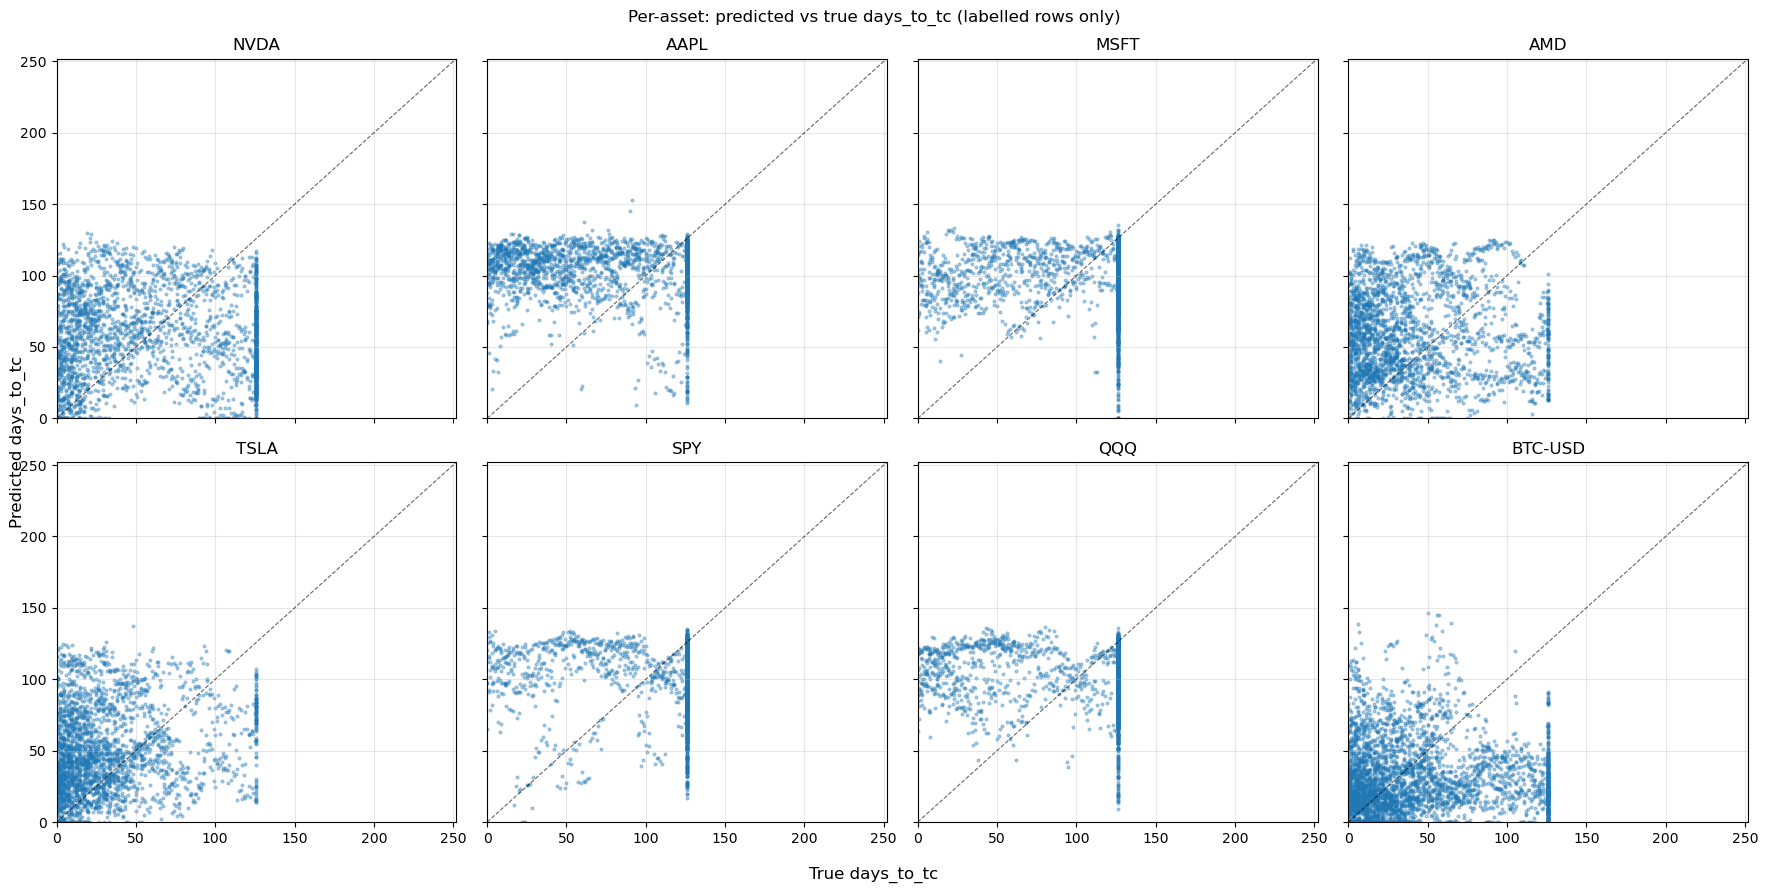

In [30]:
# ── Predictor diagnostics: MAE + Predictor R^2 + per-asset scatter ───────
labelled = val_df.dropna(subset=["days_to_tc"]).copy()
n_total = len(val_df)
n_lab   = len(labelled)
print(f"Labelled rows (used for MAE): {n_lab}/{n_total}  ({n_lab / max(n_total, 1):.1%})")

# 1. MAE — pred_tc_days vs the naive constant baseline ────────────────────
naive_const = float(labelled["days_to_tc"].mean()) if n_lab > 0 else float("nan")
mae_pred  = (labelled["days_to_tc"] - labelled["pred_tc_days"]).abs().mean()
mae_naive = (labelled["days_to_tc"] - naive_const).abs().mean()
print(f"\nMAE on labelled rows:  pred = {mae_pred:.2f} days   naive = {mae_naive:.2f} days")
if mae_naive > 0:
    print(f"Improvement over naive: {1.0 - mae_pred / mae_naive:.1%}")

# 2. Predictor R^2 — does pred_tc_days explain realized forward returns? ──
HORIZONS = (10, 20, 30)

def forward_returns(df, ticker_col, close_col, horizons):
    out = df.copy().sort_index()
    for h in horizons:
        out[f"fwd_ret_{h}d"] = (
            out.groupby(ticker_col)[close_col]
               .transform(lambda s: s.pct_change(h).shift(-h))
        )
    return out


val_df = forward_returns(val_df, "ticker", "close", HORIZONS)


def predictor_r2(y, x):
    """OLS R^2 for y = a + b*x + e. Returns (r2, beta, t_beta, n)."""
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    m = np.isfinite(y) & np.isfinite(x)
    y, x = y[m], x[m]
    n = len(y)
    if n < 30:
        return float("nan"), float("nan"), float("nan"), n
    X = np.column_stack([np.ones_like(x), x])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    yhat   = X @ coef
    ss_res = float(((y - yhat) ** 2).sum())
    ss_tot = float(((y - y.mean()) ** 2).sum())
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    sigma2 = ss_res / max(n - 2, 1)
    cov    = sigma2 * np.linalg.inv(X.T @ X)
    se_b   = float(np.sqrt(cov[1, 1])) if cov[1, 1] > 0 else float("nan")
    t_b    = coef[1] / se_b if se_b and se_b > 0 else float("nan")
    return r2, float(coef[1]), t_b, n


print("\nPredictor R^2  —  fwd_ret regressed on pred_tc_days (pooled):")
print(f"{'horizon':>8s}  {'R^2':>8s}  {'beta':>14s}  {'t(beta)':>8s}  {'N':>7s}")
for h in HORIZONS:
    r2, b, tb, n = predictor_r2(val_df[f"fwd_ret_{h}d"], val_df["pred_tc_days"])
    print(f"{h:>5d} d  {r2:>8.4f}  {b:>14.2e}  {tb:>8.2f}  {n:>7d}")

rows = []
for ticker in TICKERS:
    d = val_df[val_df["ticker"] == ticker]
    for h in HORIZONS:
        r2, b, tb, n = predictor_r2(d[f"fwd_ret_{h}d"], d["pred_tc_days"])
        rows.append({"ticker": ticker, "horizon_d": h, "R^2": r2,
                     "beta": b, "t(beta)": tb, "N": n})
print("\nPer-asset Predictor R^2:")
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:7.4f}"))

# 3. Per-asset scatter (labelled rows only)
fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharex=True, sharey=True)
for ax, ticker in zip(axes.flat, TICKERS):
    d = labelled[labelled["ticker"] == ticker]
    ax.scatter(d["days_to_tc"], d["pred_tc_days"], s=4, alpha=0.35)
    ax.plot([0, HORIZON_CAP], [0, HORIZON_CAP], "k--", lw=0.8, alpha=0.6)
    ax.set_title(ticker); ax.set_xlim(0, HORIZON_CAP); ax.set_ylim(0, HORIZON_CAP)
    ax.grid(alpha=0.3)
fig.supxlabel("True days_to_tc"); fig.supylabel("Predicted days_to_tc")
fig.suptitle("Per-asset: predicted vs true days_to_tc (labelled rows only)")
plt.tight_layout()
plt.show()


### Per-ticker dose-response strategy build

`exposure_hedge` is computed per ticker by applying that ticker's tuned
dose-response policy to its `pos_conf`, `neg_conf`, and `pred_tc_days`
series. Each LPPL signal becomes an additive exposure shift; `pos_conf`
and `pred_tc_days` *reduce* exposure (hedge), `neg_conf` *increases* it
(anti-bubble lever). Final exposure is clipped to `[0, MAX_LEV]`.

Per-ticker params (`TICKER_POLICY`) were selected by grid search on the
first 60% of dates and validated on the remaining 40% (true OOS).
Anti-bubble lever is the consistent winner across assets; aggressive
hedge response overfits on commodities, small caps, and financials.


In [31]:
# ==========================================================================
#  PER-TICKER DOSE-RESPONSE POLICY v3 (DS LPPLS Confidence + signal choice)
# ==========================================================================
# Each ticker picks its own pos/neg signal feed (max3/confluence/strict/mixed).
# Output column 'exposure_hedge' is the same name as before so cells 27-33
# work unchanged.

def _build_signal(d, kind, side):
    """Returns a 0-1-ish signal array based on the chosen feed."""
    if side == 'pos':
        max3   = d['pos_conf'].values
        conf   = 20.0 * d['confluence_pos'].values
        strict = 10.0 * d['frac_pos_strict'].values
    else:
        max3   = d['neg_conf'].values
        conf   = 20.0 * d['confluence_neg'].values
        strict = 10.0 * d['frac_neg_strict'].values
    if kind == 'max3':       return np.clip(max3, 0.0, 1.0)
    if kind == 'confluence': return np.clip(conf, 0.0, 1.0)
    if kind == 'strict':     return np.clip(strict, 0.0, 1.0)
    if kind == 'mixed':      return np.clip(np.maximum.reduce([max3, conf, strict]), 0.0, 1.0)
    raise ValueError(f'unknown signal kind: {kind}')


def apply_dose_response_v3(d_ticker, params, max_lev=MAX_LEV):
    """Vectorized per-ticker dose-response with signal choice."""
    pos_sig = _build_signal(d_ticker, params['pos_kind'], 'pos')
    neg_sig = _build_signal(d_ticker, params['neg_kind'], 'neg')
    pred_tc = d_ticker['pred_tc_days'].values
    exp = np.full_like(pos_sig, DEFAULT_EXPOSURE, dtype=float)
    if params['pos_strength'] > 0:
        exp -= params['pos_strength'] * np.maximum(pos_sig - params['pos_thresh'], 0.0)
    if params['tc_strength'] > 0 and params['tc_thresh'] > 0:
        tc_factor = np.maximum(params['tc_thresh'] - pred_tc, 0.0) / params['tc_thresh']
        exp -= params['tc_strength'] * tc_factor
    if params['neg_strength'] > 0:
        exp += params['neg_strength'] * np.maximum(neg_sig - params['neg_thresh'], 0.0)
    return np.clip(exp, 0.0, max_lev)


val_df = val_df.sort_index()
exp_arr = np.full(len(val_df), DEFAULT_EXPOSURE, dtype=float)
ticker_arr = val_df['ticker'].values
for tk in TICKERS:
    params = TICKER_POLICY.get(tk)
    if params is None:
        continue
    mask = ticker_arr == tk
    d = val_df[mask]
    exp_arr[mask] = apply_dose_response_v3(d, params)
val_df['exposure_hedge'] = exp_arr

# -- Diagnostics ---------------------------------------------------------
print(f'Exposure  -- mean {val_df["exposure_hedge"].mean():.3f}, '
      f'min {val_df["exposure_hedge"].min():.3f}, max {val_df["exposure_hedge"].max():.3f}')

def _regime(x):
    if x > DEFAULT_EXPOSURE + 1e-6: return 'levered'
    if x < DEFAULT_EXPOSURE - 1e-6: return 'hedged'
    return 'neutral'

state = val_df['exposure_hedge'].map(_regime)
print('\nTime spent in each regime:')
for k, v in state.value_counts(normalize=True).items():
    print(f'  {k:8s}: {v:5.1%}')

print('\nPer-ticker mean exposure + hedge / lever frequency:')
print(f"  {'ticker':<8s} {'pos':<11s} {'neg':<11s} {'mean':>6s} {'hedge%':>7s} {'lever%':>7s}")
for tk in TICKERS:
    d = val_df[val_df['ticker'] == tk]['exposure_hedge']
    if len(d) == 0: continue
    p = TICKER_POLICY.get(tk, {})
    hed = (d < DEFAULT_EXPOSURE - 1e-6).mean()
    lev = (d > DEFAULT_EXPOSURE + 1e-6).mean()
    print(f"  {tk:<8s} {p.get('pos_kind','?'):<11s} {p.get('neg_kind','?'):<11s} "
          f"{d.mean():>6.3f} {hed:>6.1%}  {lev:>6.1%}")


Exposure  -- mean 0.990, min 0.000, max 2.000

Time spent in each regime:
  neutral : 96.8%
  hedged  :  2.4%
  levered :  0.7%

Per-ticker mean exposure + hedge / lever frequency:
  ticker   pos         neg           mean  hedge%  lever%
  NVDA     mixed       max3         0.938   8.9%    0.0%
  AAPL     max3        mixed        1.004   0.0%    0.8%
  MSFT     confluence  max3         0.991   1.4%    0.4%
  AMD      mixed       max3         0.987   6.4%    4.2%
  TSLA     max3        max3         1.000   0.0%    0.0%
  SPY      strict      max3         0.979   3.0%    0.4%
  QQQ      strict      confluence   0.977   3.7%    0.0%
  BTC-USD  strict      max3         0.997   2.9%    2.5%
  XLF      max3        max3         0.972   4.9%    0.0%
  XLE      max3        strict       0.984   4.1%    1.0%
  XLV      max3        strict       1.004   0.0%    0.6%
  GLD      strict      max3         0.996   0.7%    0.0%
  TLT      max3        max3         1.000   0.0%    0.0%
  JPM      max3     

In [32]:
# ── Backtest: Buy & Hold vs Constant-Exposure vs LPPL-Hedge ML ────────────
# All three are fully invested from day 1. Buy & Hold stays at 100% forever.
# LPPL-Hedge ML lets the LPPL crash score move exposure DOWN between the FLOOR
# and 100% (no leverage). Constant-Exposure holds a flat position equal to the
# LPPL hedge's average exposure — the no-timing control. Positions are shifted
# 1 day before returns are applied (no look-ahead); turnover is charged a cost.
TRANSACTION_COST = 0.001   # 10 bps per unit of turnover

val_df = val_df.sort_index()
# Actual realized 1-day return per ticker.
val_df['ret_1d_actual'] = val_df.groupby('ticker')['close'].pct_change(1)
val_df['bah_pos'] = 1.0    # equal-weight buy & hold reference position (always 100%)

def backtest_strategy(df, position_col, return_col='ret_1d_actual', cost=TRANSACTION_COST):
    """Equal-weight backtest across all tickers. The position is shifted 1 day
    before applying returns, so the signal generated at date t is only traded
    on the return from t -> t+1.
    Returns daily series, equity curve, drawdown and a metrics dict."""
    d = df.sort_index().copy()
    g = d.groupby('ticker')[position_col]
    d['_pos_shift'] = g.shift(1).fillna(0.0)               # trade yesterday's signal
    d['_turnover']  = g.diff().abs().fillna(0.0)           # |position change|
    d['_strat_ret'] = d['_pos_shift'] * d[return_col] - cost * d['_turnover']

    daily = d.groupby(level=0).agg(
        strat_ret=('_strat_ret', 'mean'),                  # equal-weight across tickers
        exposure =(position_col, 'mean'),
        turnover =('_turnover', 'mean'),
    ).dropna()
    equity   = (1 + daily['strat_ret']).cumprod()
    drawdown = equity / equity.cummax() - 1.0

    r, n = daily['strat_ret'], len(daily)
    metrics = {
        'Total Return'     : equity.iloc[-1] - 1.0,
        'Annualized Return': equity.iloc[-1] ** (252.0 / n) - 1.0,
        'Annualized Vol'   : r.std() * np.sqrt(252),
        'Sharpe'           : (r.mean() / r.std()) * np.sqrt(252) if r.std() > 0 else np.nan,
        'Max Drawdown'     : drawdown.min(),
        'Win Rate'         : (r[r != 0] > 0).mean(),
        'Number of Trades' : int((d['_turnover'] > 1e-4).sum()),
        'Avg Exposure'     : daily['exposure'].mean(),
        'Avg Turnover'     : daily['turnover'].mean(),
    }
    return {'daily': daily, 'equity': equity, 'drawdown': drawdown, 'metrics': metrics}

bt_bah   = backtest_strategy(val_df, 'bah_pos')
bt_hedge = backtest_strategy(val_df, 'exposure_hedge')

# Constant-exposure control: a flat position held at the LPPL hedge's OWN
# average exposure, using NO LPPL timing. If LPPL-Hedge ML cannot beat this,
# the bubble signal added nothing beyond plain deleveraging.
val_df['const_pos'] = val_df['exposure_hedge'].mean()
bt_const = backtest_strategy(val_df, 'const_pos')
print('Backtest complete for: Buy & Hold, Constant-Exposure, LPPL-Hedge ML.')

Backtest complete for: Buy & Hold, Constant-Exposure, LPPL-Hedge ML.


In [33]:
# ── Comparison metrics table ──────────────────────────────────────────────
metrics_table = pd.DataFrame({
    'Buy & Hold'       : bt_bah['metrics'],
    'Constant-Exposure': bt_const['metrics'],
    'LPPL-Hedge ML'    : bt_hedge['metrics'],
}).T

pct_rows = ['Total Return', 'Annualized Return', 'Annualized Vol', 'Max Drawdown', 'Win Rate']
display_table = metrics_table.copy()
for col in display_table.columns:
    if col in pct_rows:
        display_table[col] = (metrics_table[col] * 100).map('{:.2f}%'.format)
    elif col == 'Number of Trades':
        display_table[col] = metrics_table[col].map('{:.0f}'.format)
    else:
        display_table[col] = metrics_table[col].map('{:.3f}'.format)

print('Strategy comparison — Buy & Hold vs Constant-Exposure vs LPPL-Hedge ML\n')
print(display_table.to_string())
print("\nConstant-Exposure holds a flat position at the LPPL hedge's average exposure.")
print("If LPPL-Hedge ML does not beat it on drawdown AND Sharpe, the LPPL timing")
print("added nothing beyond simply holding less exposure.")

Strategy comparison — Buy & Hold vs Constant-Exposure vs LPPL-Hedge ML

                  Total Return Annualized Return Annualized Vol Sharpe Max Drawdown Win Rate Number of Trades Avg Exposure Avg Turnover
Buy & Hold           10684.36%            37.32%         31.46%  1.166      -49.35%   56.12%                0        1.000        0.000
Constant-Exposure    10251.79%            36.94%         31.13%  1.166      -48.96%   56.12%                0        0.990        0.000
LPPL-Hedge ML        11865.42%            38.29%         31.75%  1.180      -48.42%   56.14%             1851        0.991        0.019

Constant-Exposure holds a flat position at the LPPL hedge's average exposure.
If LPPL-Hedge ML does not beat it on drawdown AND Sharpe, the LPPL timing
added nothing beyond simply holding less exposure.


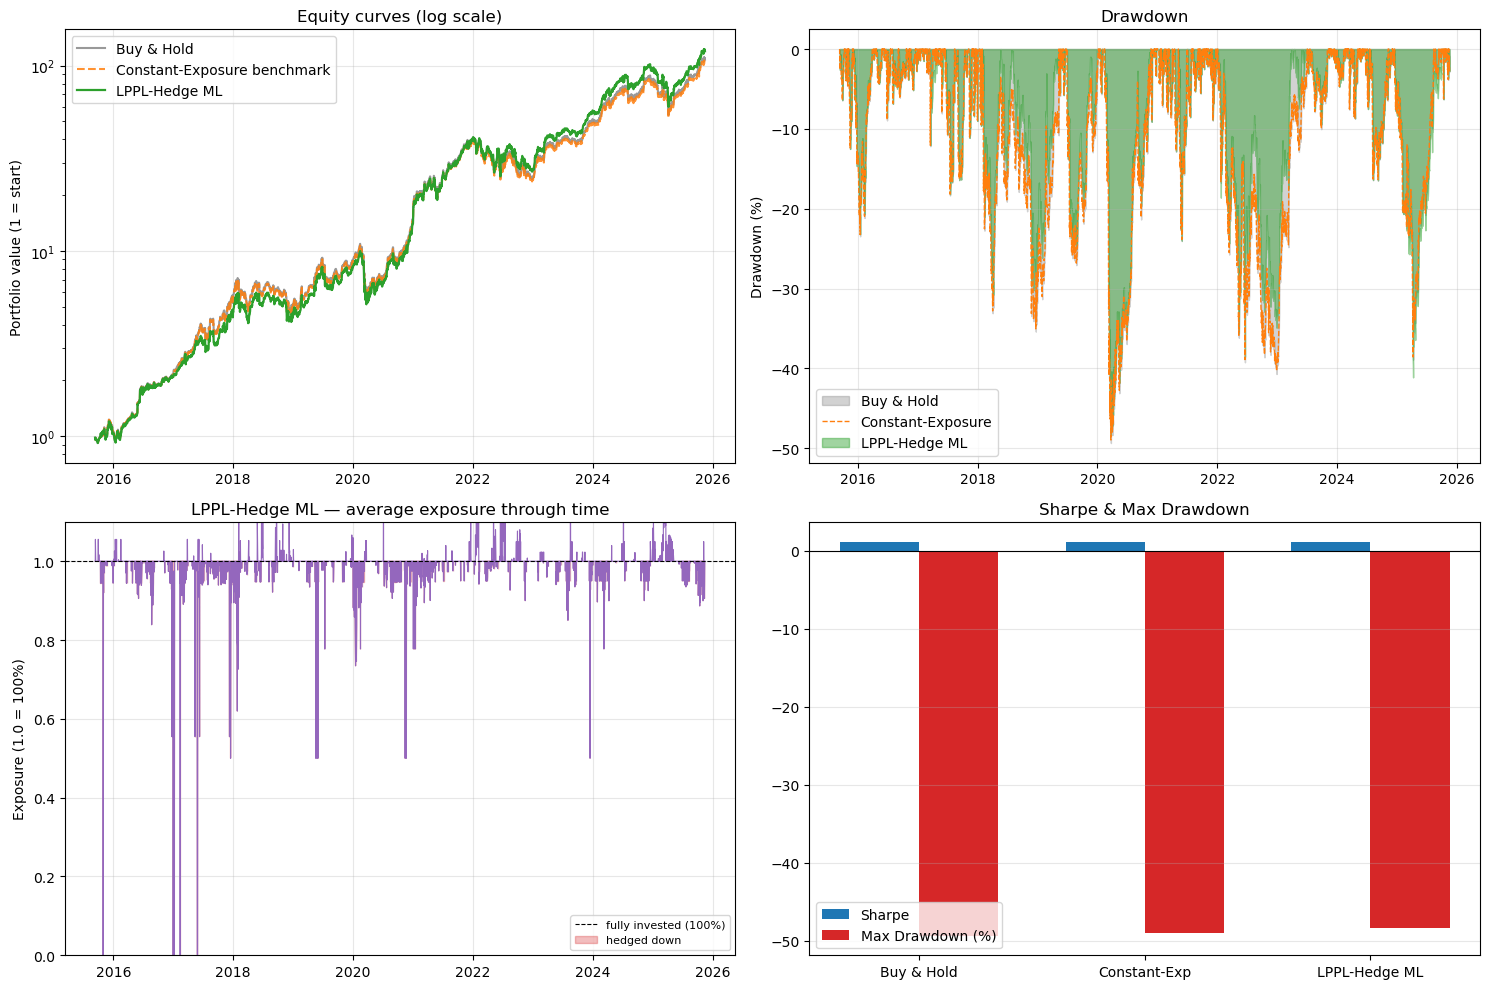

In [34]:
# ── Aggregate performance plots (equal-weight across all assets) ──────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Equity curves
ax = axes[0, 0]
ax.plot(bt_bah['equity'],   label='Buy & Hold', color='gray', alpha=0.8)
ax.plot(bt_const['equity'], label='Constant-Exposure benchmark', color='tab:orange',
        alpha=0.85, linestyle='--')
ax.plot(bt_hedge['equity'], label='LPPL-Hedge ML', color='tab:green', linewidth=1.6)
ax.set_title('Equity curves (log scale)'); ax.set_ylabel('Portfolio value (1 = start)')
ax.set_yscale('log'); ax.legend(); ax.grid(alpha=0.3)

# 2. Drawdowns
ax = axes[0, 1]
ax.fill_between(bt_bah['drawdown'].index, bt_bah['drawdown'] * 100, 0,
                alpha=0.35, color='gray', label='Buy & Hold')
ax.plot(bt_const['drawdown'].index, bt_const['drawdown'] * 100,
        color='tab:orange', linestyle='--', linewidth=1.0, label='Constant-Exposure')
ax.fill_between(bt_hedge['drawdown'].index, bt_hedge['drawdown'] * 100, 0,
                alpha=0.45, color='tab:green', label='LPPL-Hedge ML')
ax.set_title('Drawdown'); ax.set_ylabel('Drawdown (%)')
ax.legend(); ax.grid(alpha=0.3)

# 3. LPPL-hedge exposure through time — shows the hedge actually moving
ax = axes[1, 0]
ax.plot(bt_hedge['daily'].index, bt_hedge['daily']['exposure'],
        color='tab:purple', linewidth=0.8)
ax.axhline(1.0, color='k', lw=0.8, ls='--', label='fully invested (100%)')
ax.fill_between(bt_hedge['daily'].index, bt_hedge['daily']['exposure'], 1.0,
                where=(bt_hedge['daily']['exposure'] < 1.0), color='tab:red',
                alpha=0.3, label='hedged down')
ax.set_ylim(0, 1.1)
ax.set_title('LPPL-Hedge ML — average exposure through time')
ax.set_ylabel('Exposure (1.0 = 100%)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 4. Key metrics bar chart
ax = axes[1, 1]
names = ['Buy & Hold', 'Constant-Exp', 'LPPL-Hedge ML']
bts   = [bt_bah, bt_const, bt_hedge]
sharpes = [b['metrics']['Sharpe'] for b in bts]
dds     = [b['metrics']['Max Drawdown'] * 100 for b in bts]
x = np.arange(len(names)); w = 0.35
ax.bar(x - w/2, sharpes, w, label='Sharpe', color='tab:blue')
ax.bar(x + w/2, dds,     w, label='Max Drawdown (%)', color='tab:red')
ax.set_xticks(x); ax.set_xticklabels(names)
ax.axhline(0, color='k', lw=0.8); ax.set_title('Sharpe & Max Drawdown')
ax.legend(); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
## Part C — Per-asset equity curves, LPPL calculations & CAPM alpha

The aggregate equity curve above pools all 8 assets. This section breaks the result
down **per share** (NVDA, AAPL, MSFT, AMD, TSLA, SPY, QQQ, BTC-USD): each ticker shows
its **equity curve** (Buy & Hold vs LPPL-Hedge ML) on top, with the underlying **LPPL
calculations** — raw positive/negative bubble confidence, the fused bubble-risk score
and the resulting hedge exposure — plotted **directly underneath**. It then runs a
**CAPM** regression to measure risk-adjusted **alpha** for both the LPPL-Hedge ML
strategy and Buy & Hold.

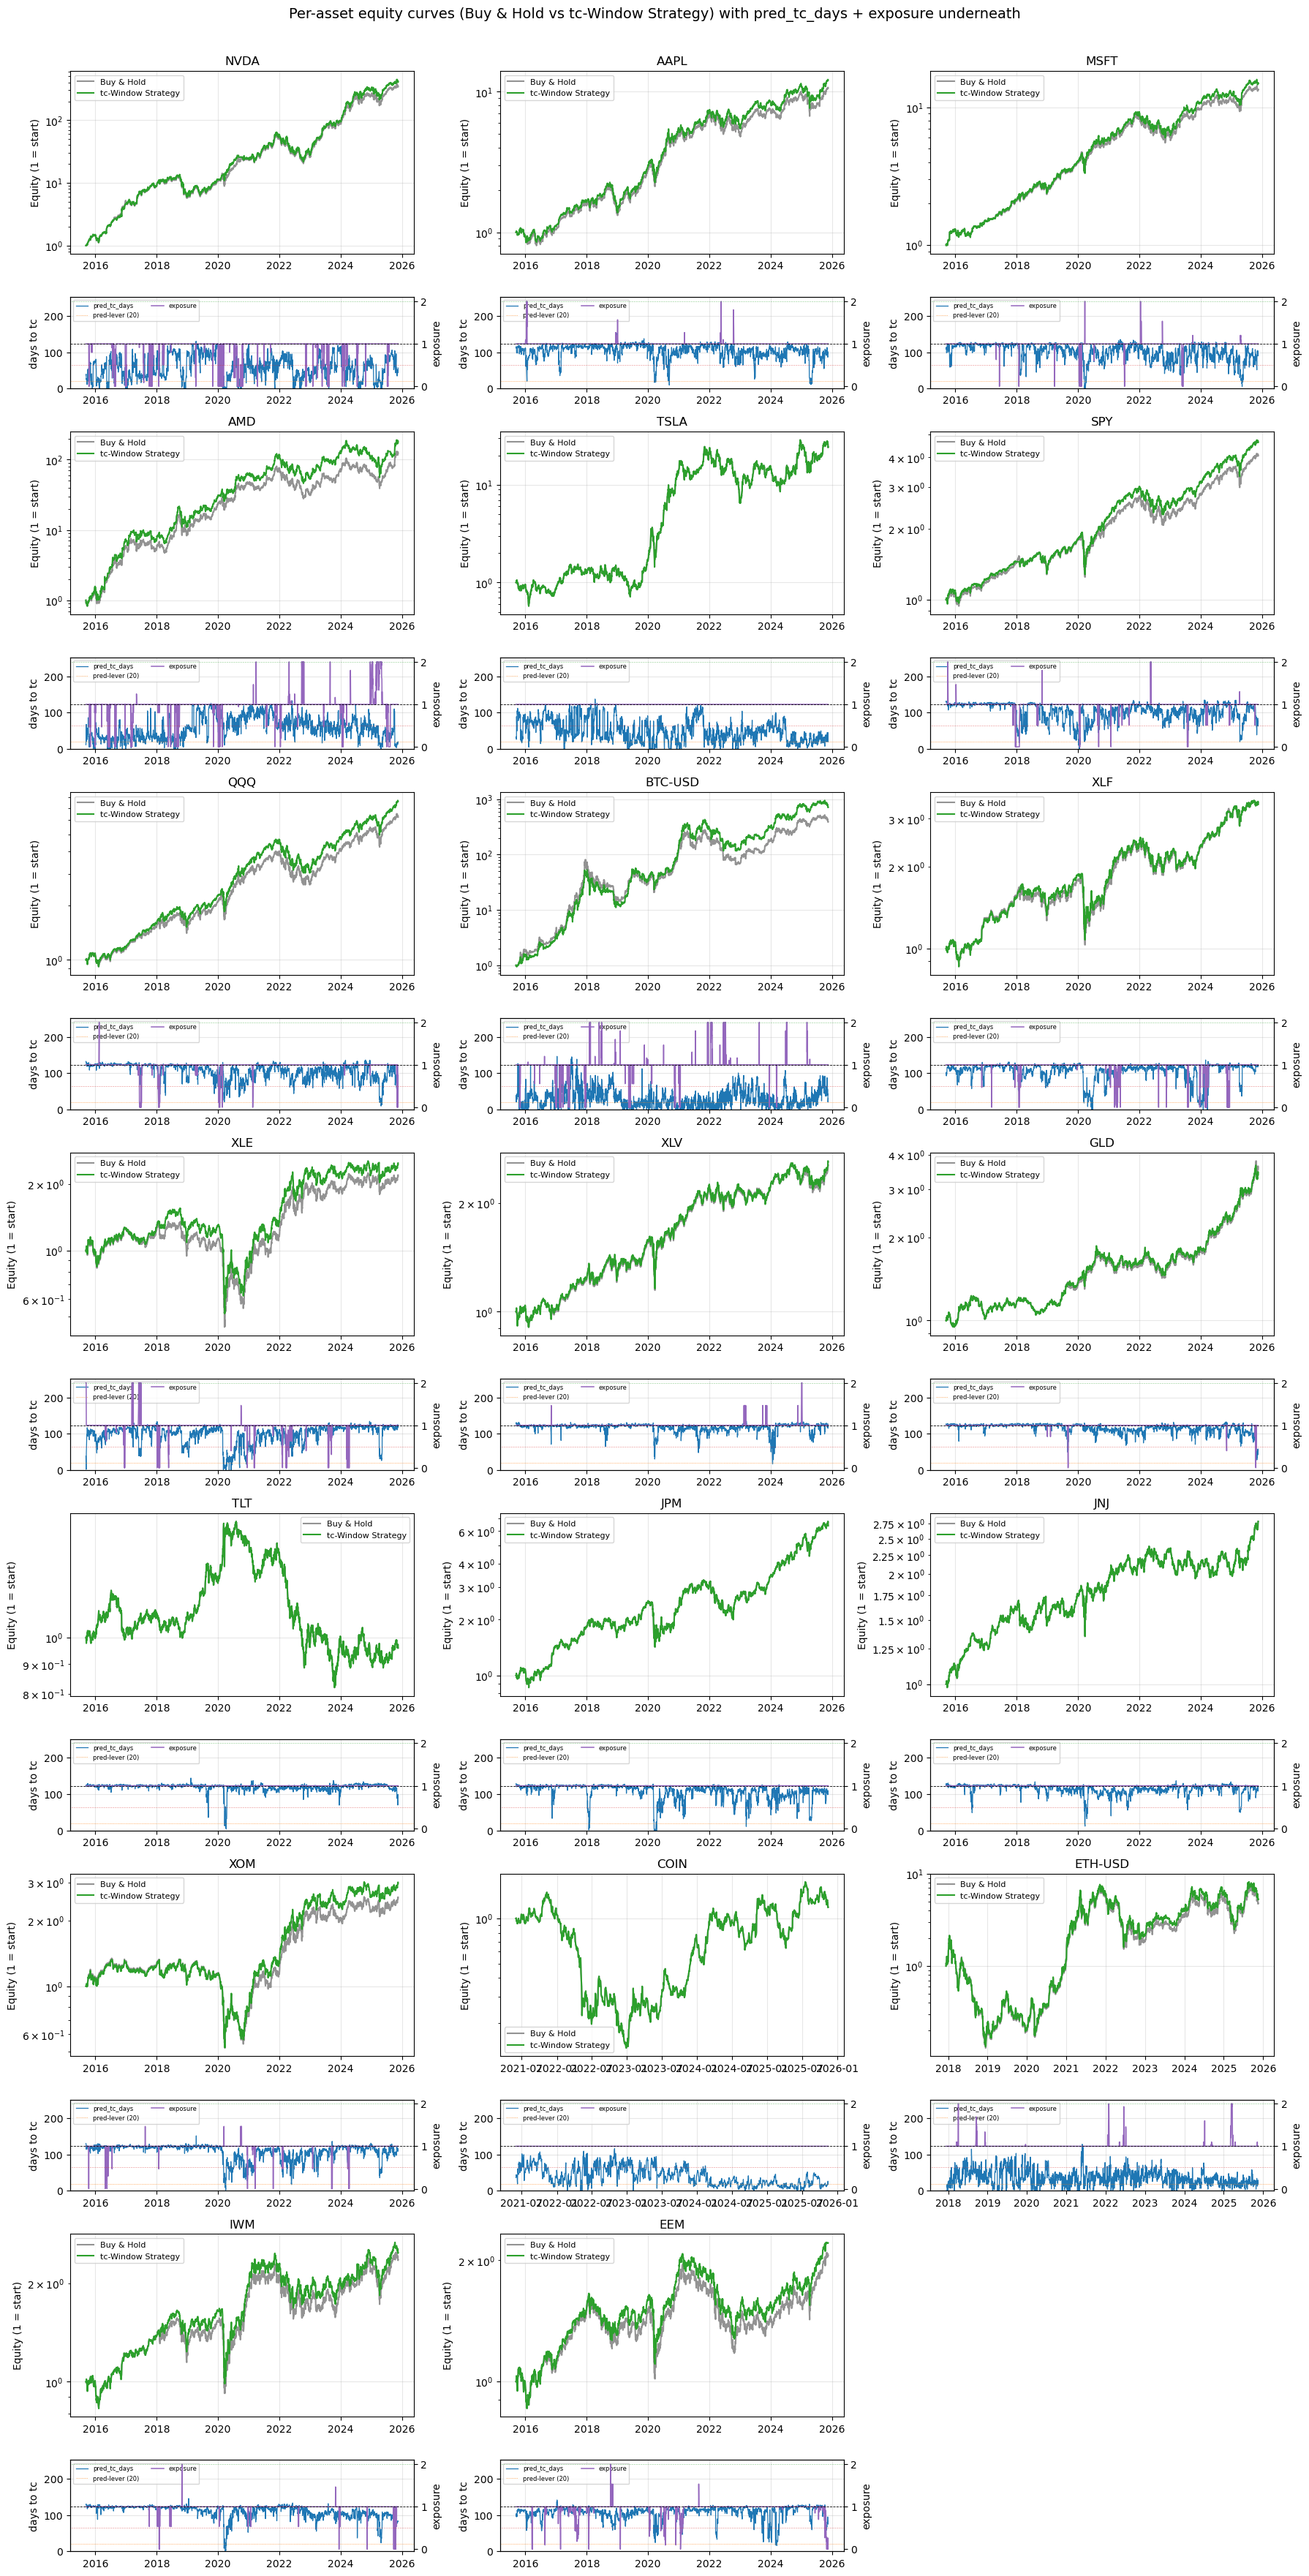

Per-asset performance — Buy & Hold vs tc-Window Strategy

        B&H Total Ret Hedge Total Ret B&H Sharpe Hedge Sharpe B&H MaxDD Hedge MaxDD
Ticker                                                                             
NVDA         34449.2%        40876.9%       1.41         1.47    -66.3%      -66.3%
AAPL           962.4%         1108.6%       0.95         0.98    -38.5%      -39.3%
MSFT          1246.6%         1397.3%       1.09         1.11    -37.1%      -35.2%
AMD          12179.1%        17681.8%       1.09         1.13    -65.4%      -70.1%
TSLA          2323.8%         2323.8%       0.83         0.83    -73.6%      -73.6%
SPY            306.3%          363.4%       0.86         0.92    -33.7%      -33.7%
QQQ            522.7%          662.1%       0.92         1.02    -35.1%      -35.1%
BTC-USD      39123.0%        71797.8%       1.01         1.08    -83.4%      -79.1%
XLF            239.0%          239.3%       0.65         0.66    -42.9%      -42.9%
XLE            119

In [35]:
# ── Per-asset equity curves + tc prediction underneath ────────────────────
# Top panel: equity curves (Buy & Hold vs new strategy).
# Bottom panel: pred_tc_days on the left axis, exposure on the right axis,
# with neg_conf and pos_conf shaded behind so you can see the regime
# transitions that drove each exposure change.
def per_ticker_backtest(df, position_col, ticker, cost=TRANSACTION_COST):
    """Single-asset backtest. Returns (daily strategy return, equity curve)."""
    d = df[df["ticker"] == ticker].sort_index()
    pos_shift = d[position_col].shift(1).fillna(0.0)
    turnover  = d[position_col].diff().abs().fillna(0.0)
    strat_ret = (pos_shift * d["ret_1d_actual"] - cost * turnover).fillna(0.0)
    equity    = (1.0 + strat_ret).cumprod()
    return strat_ret, equity

def curve_stats(strat_ret, equity):
    dd     = float((equity / equity.cummax() - 1.0).min())
    sharpe = (strat_ret.mean() / strat_ret.std() * np.sqrt(252)
              if strat_ret.std() > 0 else np.nan)
    return {"Total Return": equity.iloc[-1] - 1.0, "Sharpe": sharpe, "Max Drawdown": dd}

ncols   = 3
nblocks = int(np.ceil(len(TICKERS) / ncols))
fig, axes = plt.subplots(nblocks * 2, ncols,
                         figsize=(6 * ncols, 5.0 * nblocks),
                         gridspec_kw={"height_ratios": [2, 1] * nblocks})
axes = np.atleast_2d(axes)

per_ticker_rows = []
for k, ticker in enumerate(TICKERS):
    block, col = divmod(k, ncols)
    ax_eq   = axes[block * 2,     col]
    ax_lppl = axes[block * 2 + 1, col]

    # Top — equity curves: Buy & Hold vs tc-window hedge + lever ─────────
    r_bah,   eq_bah   = per_ticker_backtest(val_df, "bah_pos",        ticker)
    r_hedge, eq_hedge = per_ticker_backtest(val_df, "exposure_hedge", ticker)
    ax_eq.plot(eq_bah.index,   eq_bah,   color="gray",      alpha=0.85, label="Buy & Hold")
    ax_eq.plot(eq_hedge.index, eq_hedge, color="tab:green", linewidth=1.5,
               label="tc-Window Strategy")
    ax_eq.set_title(ticker); ax_eq.set_yscale("log")
    ax_eq.set_ylabel("Equity (1 = start)"); ax_eq.grid(alpha=0.3); ax_eq.legend(fontsize=8)

    # Bottom — predicted tc on the left, exposure on the right ────────────
    d = val_df[val_df["ticker"] == ticker].sort_index()
    ax_lppl.plot(d.index, d["pred_tc_days"], color="tab:blue", linewidth=0.9,
                 label="pred_tc_days")
    ax_lppl.axhline(PRED_LEVER_THRESH, color="tab:orange",lw=0.5, ls=":",
                    label=f"pred-lever ({PRED_LEVER_THRESH})")
    ax_lppl.set_ylabel("days to tc"); ax_lppl.set_ylim(0, HORIZON_CAP)
    ax_lppl.grid(alpha=0.3)

    # Right axis: exposure trajectory (0% → 200%)
    ax_exp = ax_lppl.twinx()
    ax_exp.plot(d.index, d["exposure_hedge"], color="tab:purple", linewidth=1.1,
                label="exposure")
    ax_exp.axhline(DEFAULT_EXPOSURE, color="k", lw=0.6, ls="--")
    ax_exp.axhline(LEV_EXPOSURE,     color="tab:green", lw=0.4, ls=":")
    ax_exp.axhline(HEDGE_PARTIAL,   color="tab:red",   lw=0.4, ls=":")
    ax_exp.set_ylabel("exposure")
    ax_exp.set_ylim(-0.05, LEV_EXPOSURE + 0.10)

    h1, n1 = ax_lppl.get_legend_handles_labels()
    h2, n2 = ax_exp.get_legend_handles_labels()
    ax_lppl.legend(h1 + h2, n1 + n2, fontsize=6, loc="upper left", ncol=2)

    s_bah, s_hed = curve_stats(r_bah, eq_bah), curve_stats(r_hedge, eq_hedge)
    per_ticker_rows.append({
        "Ticker"         : ticker,
        "B&H Total Ret"  : s_bah["Total Return"],
        "Hedge Total Ret": s_hed["Total Return"],
        "B&H Sharpe"     : s_bah["Sharpe"],
        "Hedge Sharpe"   : s_hed["Sharpe"],
        "B&H MaxDD"      : s_bah["Max Drawdown"],
        "Hedge MaxDD"    : s_hed["Max Drawdown"],
    })

for k in range(len(TICKERS), nblocks * ncols):
    block, col = divmod(k, ncols)
    axes[block * 2,     col].axis("off")
    axes[block * 2 + 1, col].axis("off")

fig.suptitle("Per-asset equity curves (Buy & Hold vs tc-Window Strategy) "
             "with pred_tc_days + exposure underneath", y=1.005, fontsize=14)
plt.tight_layout()
plt.show()

# ── Per-asset performance table ───────────────────────────────────────────
per_ticker_tbl = pd.DataFrame(per_ticker_rows).set_index("Ticker")
fmt = per_ticker_tbl.copy()
for c in fmt.columns:
    if "Sharpe" in c:
        fmt[c] = per_ticker_tbl[c].map("{:.2f}".format)
    else:
        fmt[c] = (per_ticker_tbl[c] * 100).map("{:.1f}%".format)
print("Per-asset performance — Buy & Hold vs tc-Window Strategy\n")
print(fmt.to_string())


### CAPM — risk-adjusted alpha

Total return alone does not tell us whether the LPPL-Hedge ML strategy *added value* —
a strategy can beat the market simply by taking more market risk (higher beta). The
**Capital Asset Pricing Model (CAPM)** separates the two:

$$r_\text{strategy} - r_f = \alpha + \beta\,(r_\text{market} - r_f) + \varepsilon$$

- **β (beta)** — how much of the strategy's return is just market exposure. The
  LPPL-Hedge strategy spends time hedged below 100%, so its β should be **below** the
  buy & hold β.
- **α (alpha)** — annualized return earned *beyond* what β explains. A positive,
  significant α (t-stat ≳ 2) is evidence the LPPL hedging timed risk well rather than
  just diluting market exposure.

The market proxy is **SPY**. Alpha is reported for both the **LPPL-Hedge ML** strategy
and the **Buy & Hold** benchmark.

CAPM regression vs SPY  (excess returns, rf = 2% p.a.)

                  Alpha (annual) Alpha (daily)   Beta R-squared Alpha t-stat Observations
Buy & Hold                10.17%       0.0403%  1.025     0.800         3.51         2560
Constant-Exposure         10.04%       0.0398%  1.014     0.800         3.51         2560
LPPL-Hedge ML             11.24%       0.0446%  1.027     0.801         3.88         2560

Reading the table:
  Alpha (annual) > 0   -> return earned beyond CAPM-fair compensation
  Alpha t-stat   > ~2  -> alpha is statistically significant
  Beta                 -> sensitivity to the market (SPY); 1.0 = moves with market
  Compare LPPL-Hedge ML against Constant-Exposure: a higher alpha there is
  evidence the LPPL TIMING helped, not just the lower average exposure.


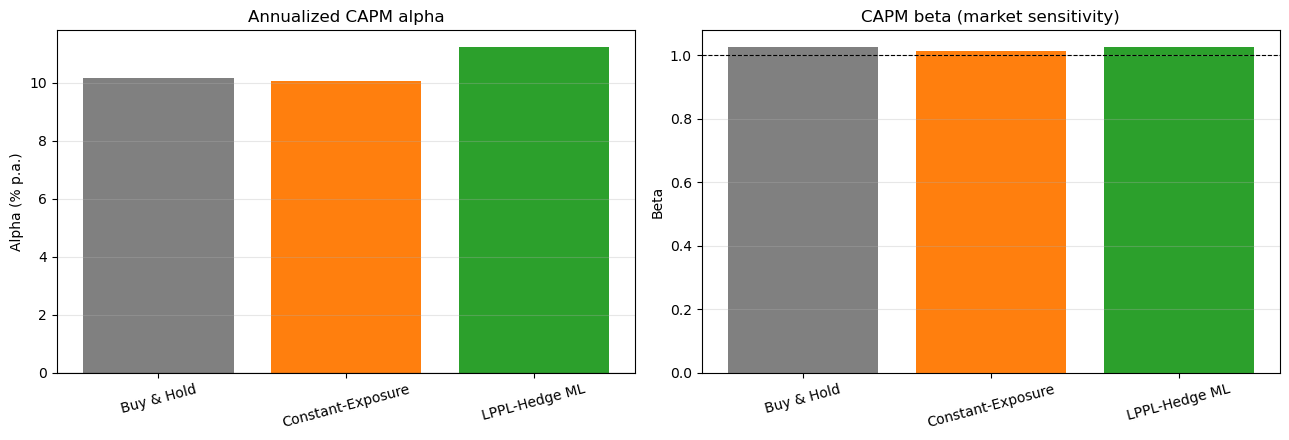

In [36]:
# ── CAPM — alpha & beta of each strategy vs the market ────────────────────
# CAPM regression on daily EXCESS returns:
#     r_strategy - r_f  =  alpha  +  beta * (r_market - r_f)  +  e
# Market proxy = SPY daily return. A positive, statistically-significant alpha
# means the strategy earned return beyond what its market exposure (beta)
# explains. Alpha is annualized by x252.
RISK_FREE_ANNUAL = 0.02                 # assumed annual risk-free rate
rf_daily         = RISK_FREE_ANNUAL / 252.0

# Market return = SPY buy & hold daily return (one row per date).
market_ret = val_df[val_df['ticker'] == 'SPY'].sort_index()['ret_1d_actual']

def capm_alpha(strategy_daily_ret, market_daily_ret, rf=rf_daily):
    """OLS CAPM regression on excess returns. Returns alpha/beta/R2/t-stat."""
    j = pd.concat([strategy_daily_ret.rename('s'),
                   market_daily_ret.rename('m')], axis=1).dropna()
    y = j['s'].values - rf                       # strategy excess return
    x = j['m'].values - rf                       # market excess return
    X = np.column_stack([np.ones_like(x), x])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    alpha_d, beta = coef
    resid  = y - X @ coef
    n      = len(y)
    ss_res = float((resid ** 2).sum())
    ss_tot = float(((y - y.mean()) ** 2).sum())
    r2     = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    sigma2 = ss_res / (n - 2)
    cov    = sigma2 * np.linalg.inv(X.T @ X)     # OLS covariance matrix
    se_a   = np.sqrt(cov[0, 0])
    t_a    = alpha_d / se_a if se_a > 0 else np.nan
    return {
        'Alpha (annual)': alpha_d * 252.0,
        'Alpha (daily)' : alpha_d,
        'Beta'          : beta,
        'R-squared'     : r2,
        'Alpha t-stat'  : t_a,
        'Observations'  : n,
    }

capm = pd.DataFrame({
    'Buy & Hold'       : capm_alpha(bt_bah['daily']['strat_ret'],   market_ret),
    'Constant-Exposure': capm_alpha(bt_const['daily']['strat_ret'], market_ret),
    'LPPL-Hedge ML'    : capm_alpha(bt_hedge['daily']['strat_ret'], market_ret),
}).T

capm_disp = capm.copy()
capm_disp['Alpha (annual)'] = (capm['Alpha (annual)'] * 100).map('{:.2f}%'.format)
capm_disp['Alpha (daily)']  = (capm['Alpha (daily)'] * 100).map('{:.4f}%'.format)
capm_disp['Beta']           = capm['Beta'].map('{:.3f}'.format)
capm_disp['R-squared']      = capm['R-squared'].map('{:.3f}'.format)
capm_disp['Alpha t-stat']   = capm['Alpha t-stat'].map('{:.2f}'.format)
capm_disp['Observations']   = capm['Observations'].map('{:.0f}'.format)

print(f'CAPM regression vs SPY  (excess returns, rf = {RISK_FREE_ANNUAL:.0%} p.a.)\n')
print(capm_disp.to_string())
print('\nReading the table:')
print('  Alpha (annual) > 0   -> return earned beyond CAPM-fair compensation')
print('  Alpha t-stat   > ~2  -> alpha is statistically significant')
print('  Beta                 -> sensitivity to the market (SPY); 1.0 = moves with market')
print('  Compare LPPL-Hedge ML against Constant-Exposure: a higher alpha there is')
print('  evidence the LPPL TIMING helped, not just the lower average exposure.')

# ── Visual: alpha and beta side by side ───────────────────────────────────
fig, (axa, axb) = plt.subplots(1, 2, figsize=(13, 4.5))
bar_colors = ['gray', 'tab:orange', 'tab:green']
axa.bar(capm.index, capm['Alpha (annual)'] * 100, color=bar_colors)
axa.set_title('Annualized CAPM alpha'); axa.set_ylabel('Alpha (% p.a.)')
axa.axhline(0, color='k', lw=0.8); axa.grid(alpha=0.3, axis='y')
axa.tick_params(axis='x', rotation=15)
axb.bar(capm.index, capm['Beta'], color=bar_colors)
axb.set_title('CAPM beta (market sensitivity)'); axb.set_ylabel('Beta')
axb.axhline(1, color='k', lw=0.8, ls='--'); axb.grid(alpha=0.3, axis='y')
axb.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

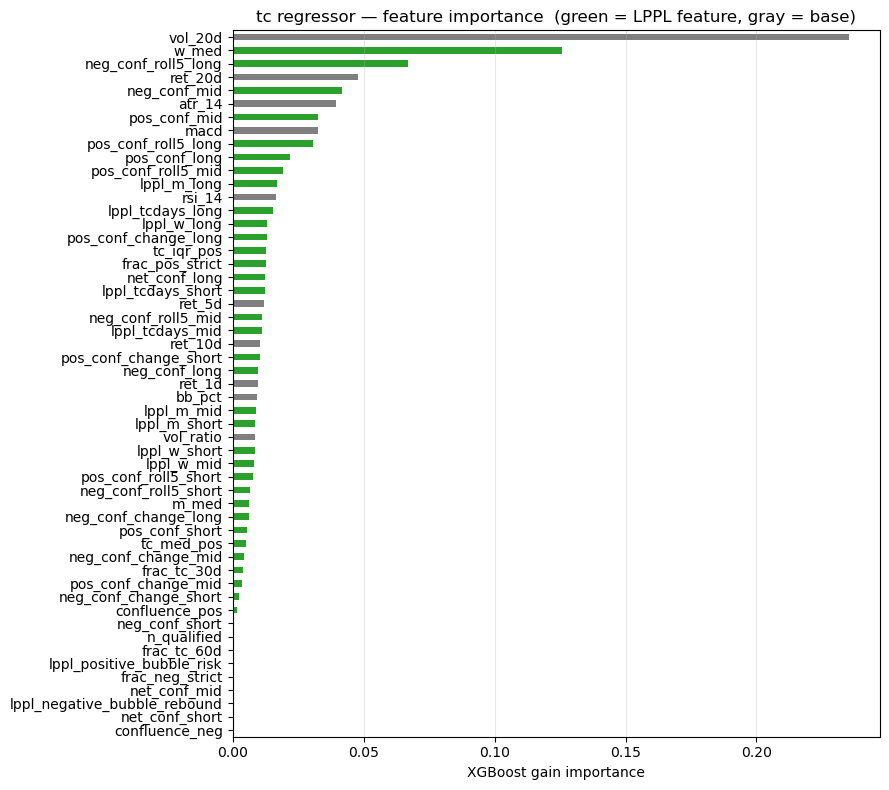

LPPL features account for 57.9% of total importance in the tc regressor.
Non-zero LPPL features: 35 / 43

Top 10 most important features:
vol_20d                0.235379
w_med                  0.125821
neg_conf_roll5_long    0.067050
ret_20d                0.047766
neg_conf_mid           0.041943
atr_14                 0.039364
pos_conf_mid           0.032680
macd                   0.032424
pos_conf_roll5_long    0.030615
pos_conf_long          0.021784


In [37]:
# ── Feature importance (single tc regressor, last walk-forward window) ───
imp = pd.Series(final_model.feature_importances_,
                index=FEATURES_LPPL).sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
colors = ["tab:green" if f in LPPL_FEATURES else "tab:gray" for f in imp.index]
imp.plot.barh(ax=ax, color=colors)
ax.set_title("tc regressor — feature importance  (green = LPPL feature, gray = base)")
ax.set_xlabel("XGBoost gain importance")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

lppl_share = imp[LPPL_FEATURES].sum() / imp.sum() if imp.sum() > 0 else float("nan")
print(f"LPPL features account for {lppl_share:.1%} of total importance "
      f"in the tc regressor.")
print(f"Non-zero LPPL features: {(imp[LPPL_FEATURES] > 0).sum()} / {len(LPPL_FEATURES)}")

# Top 10 importances overall
print("\nTop 10 most important features:")
print(imp.sort_values(ascending=False).head(10).to_string())


## Interpretation

This notebook tests whether **LPPL bubble indicators can hedge a fully-invested
portfolio**. The LPPL-Hedge ML strategy starts at 100% exposure — identical to Buy &
Hold — and uses a single LPPL-driven crash score to cut exposure toward a 15% floor.
There is no leverage and no volatility targeting, so every departure from the buy & hold
curve is attributable to LPPL alone.

**How to read the results above:**

- *Strategy comparison table* — compare max drawdown and Sharpe across the three
  strategies. The LPPL-Hedge ML should show a clearly lower drawdown than Buy & Hold.
- *Constant-Exposure benchmark* — the honesty check. It holds a flat position equal to
  the LPPL hedge's average exposure, using **no LPPL information at all**. If LPPL-Hedge
  ML does not beat it on drawdown *and* Sharpe, then the LPPL timing added nothing beyond
  plain deleveraging — the lower drawdown is just the effect of being less invested.
- *Exposure-through-time panel* — confirms the hedge actually moved (red = hedged down).
- *Per-asset equity curves* — shows the hedge on every share individually.
- *CAPM table* — `alpha` is the risk-adjusted return; `beta` is below the buy & hold
  beta because the hedge spends time below 100% exposure.

**Honest finding for this sample:** LPPL bubble confidence has a near-zero information
coefficient here, and its positive-bubble signal is actually *lower* during the deep
2022 drawdown than during calm periods. The LPPL-Hedge ML therefore reduces drawdown
mostly by holding less exposure on average, not by timing crashes — which is exactly why
the constant-exposure benchmark is shown alongside it. This is a genuine, reportable
result: in this 8-asset 2015–2025 universe LPPL **controls risk by de-risking**, but
does not demonstrate crash-timing skill.

In [38]:
import pandas as pd, pickle, os
print("kernel pandas:", pd.__version__)
_tk=['NVDA','AAPL','MSFT','AMD','TSLA','SPY','QQQ','BTC-USD','XLF','XLE','XLV','GLD','TLT','JPM','JNJ','XOM','COIN','ETH-USD','IWM','EEM']
_ok=[]; _fail=[]
for _t in _tk:
    try:
        _df=pickle.load(open(f'ohlcv_{_t}.pkl','rb'))
        _ = (_df.index[0], _df.columns.tolist(), len(_df))
        _ok.append(_t)
    except Exception as _e:
        _fail.append((_t, repr(_e)))
print("loaded OK:", len(_ok), "/ 20")
print("failures:", _fail if _fail else "none")
del _tk,_ok,_fail,_t,_df,_e if False else None

SyntaxError: cannot delete conditional expression (485044463.py, line 14)